In [1]:
from prepare_time_boroughs import prepare_yearly_boroughs, prepare_quarterly_boroughs, prepare_monthly_boroughs
from forecasting_tools import sarima_forecast, bayesian_ridge_forecast, plot_borough_forecasts, prophet_forecast, plot_prophet_forecasts
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

/opt/anaconda3/envs/london/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
df_year = prepare_yearly_boroughs()
df_quarter = prepare_quarterly_boroughs()
df_month = prepare_monthly_boroughs()

PREPARING YEARLY DATA...
COMPLETE
PREPARING QUARTERLY DATA...
COMPLETE
PREPARING MONTHLY DATA...
COMPLETE


In [3]:
quarter_positions = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44]
month_positions=[2, 14, 26, 38, 50, 62, 74, 86, 98, 110, 122, 134]
year_labels=['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028']

5 year forecast for yearly datapoints per borough

In [4]:
df_month_forecast = sarima_forecast(df_month, 72, 60)
df_quarter_forecast = sarima_forecast(df_quarter, 20, 20)

In [5]:
df_bayesian_year_forecast = bayesian_ridge_forecast(df_year, 6, 5)
df_bayesian_quarter_forecast = bayesian_ridge_forecast(df_quarter, 20, 20)
df_bayesian_month_forecast = bayesian_ridge_forecast(df_month, 72, 60)

In [6]:
df_year_covid = prepare_yearly_boroughs(ADJUST_COVID=True)
df_quarter_covid = prepare_quarterly_boroughs(ADJUST_COVID=True)
df_month_covid = prepare_monthly_boroughs(ADJUST_COVID=True)

PREPARING YEARLY DATA...
COMPLETE
PREPARING QUARTERLY DATA...
COMPLETE
PREPARING MONTHLY DATA...
COMPLETE


In [7]:
df_month_covid_forecast = sarima_forecast(df_month_covid, 72, 60)
df_quarter_covid_forecast = sarima_forecast(df_quarter_covid, 20, 20)

df_bayesian_year_covid_forecast = bayesian_ridge_forecast(df_year_covid, 6, 5)
df_bayesian_quarter_covid_forecast = bayesian_ridge_forecast(df_quarter_covid, 20, 20)
df_bayesian_month_covid_forecast = bayesian_ridge_forecast(df_month_covid, 72, 60)

------------------------------
------- SARIMA MONTHLY -------
------------------------------
average mape: 26.568388716627993


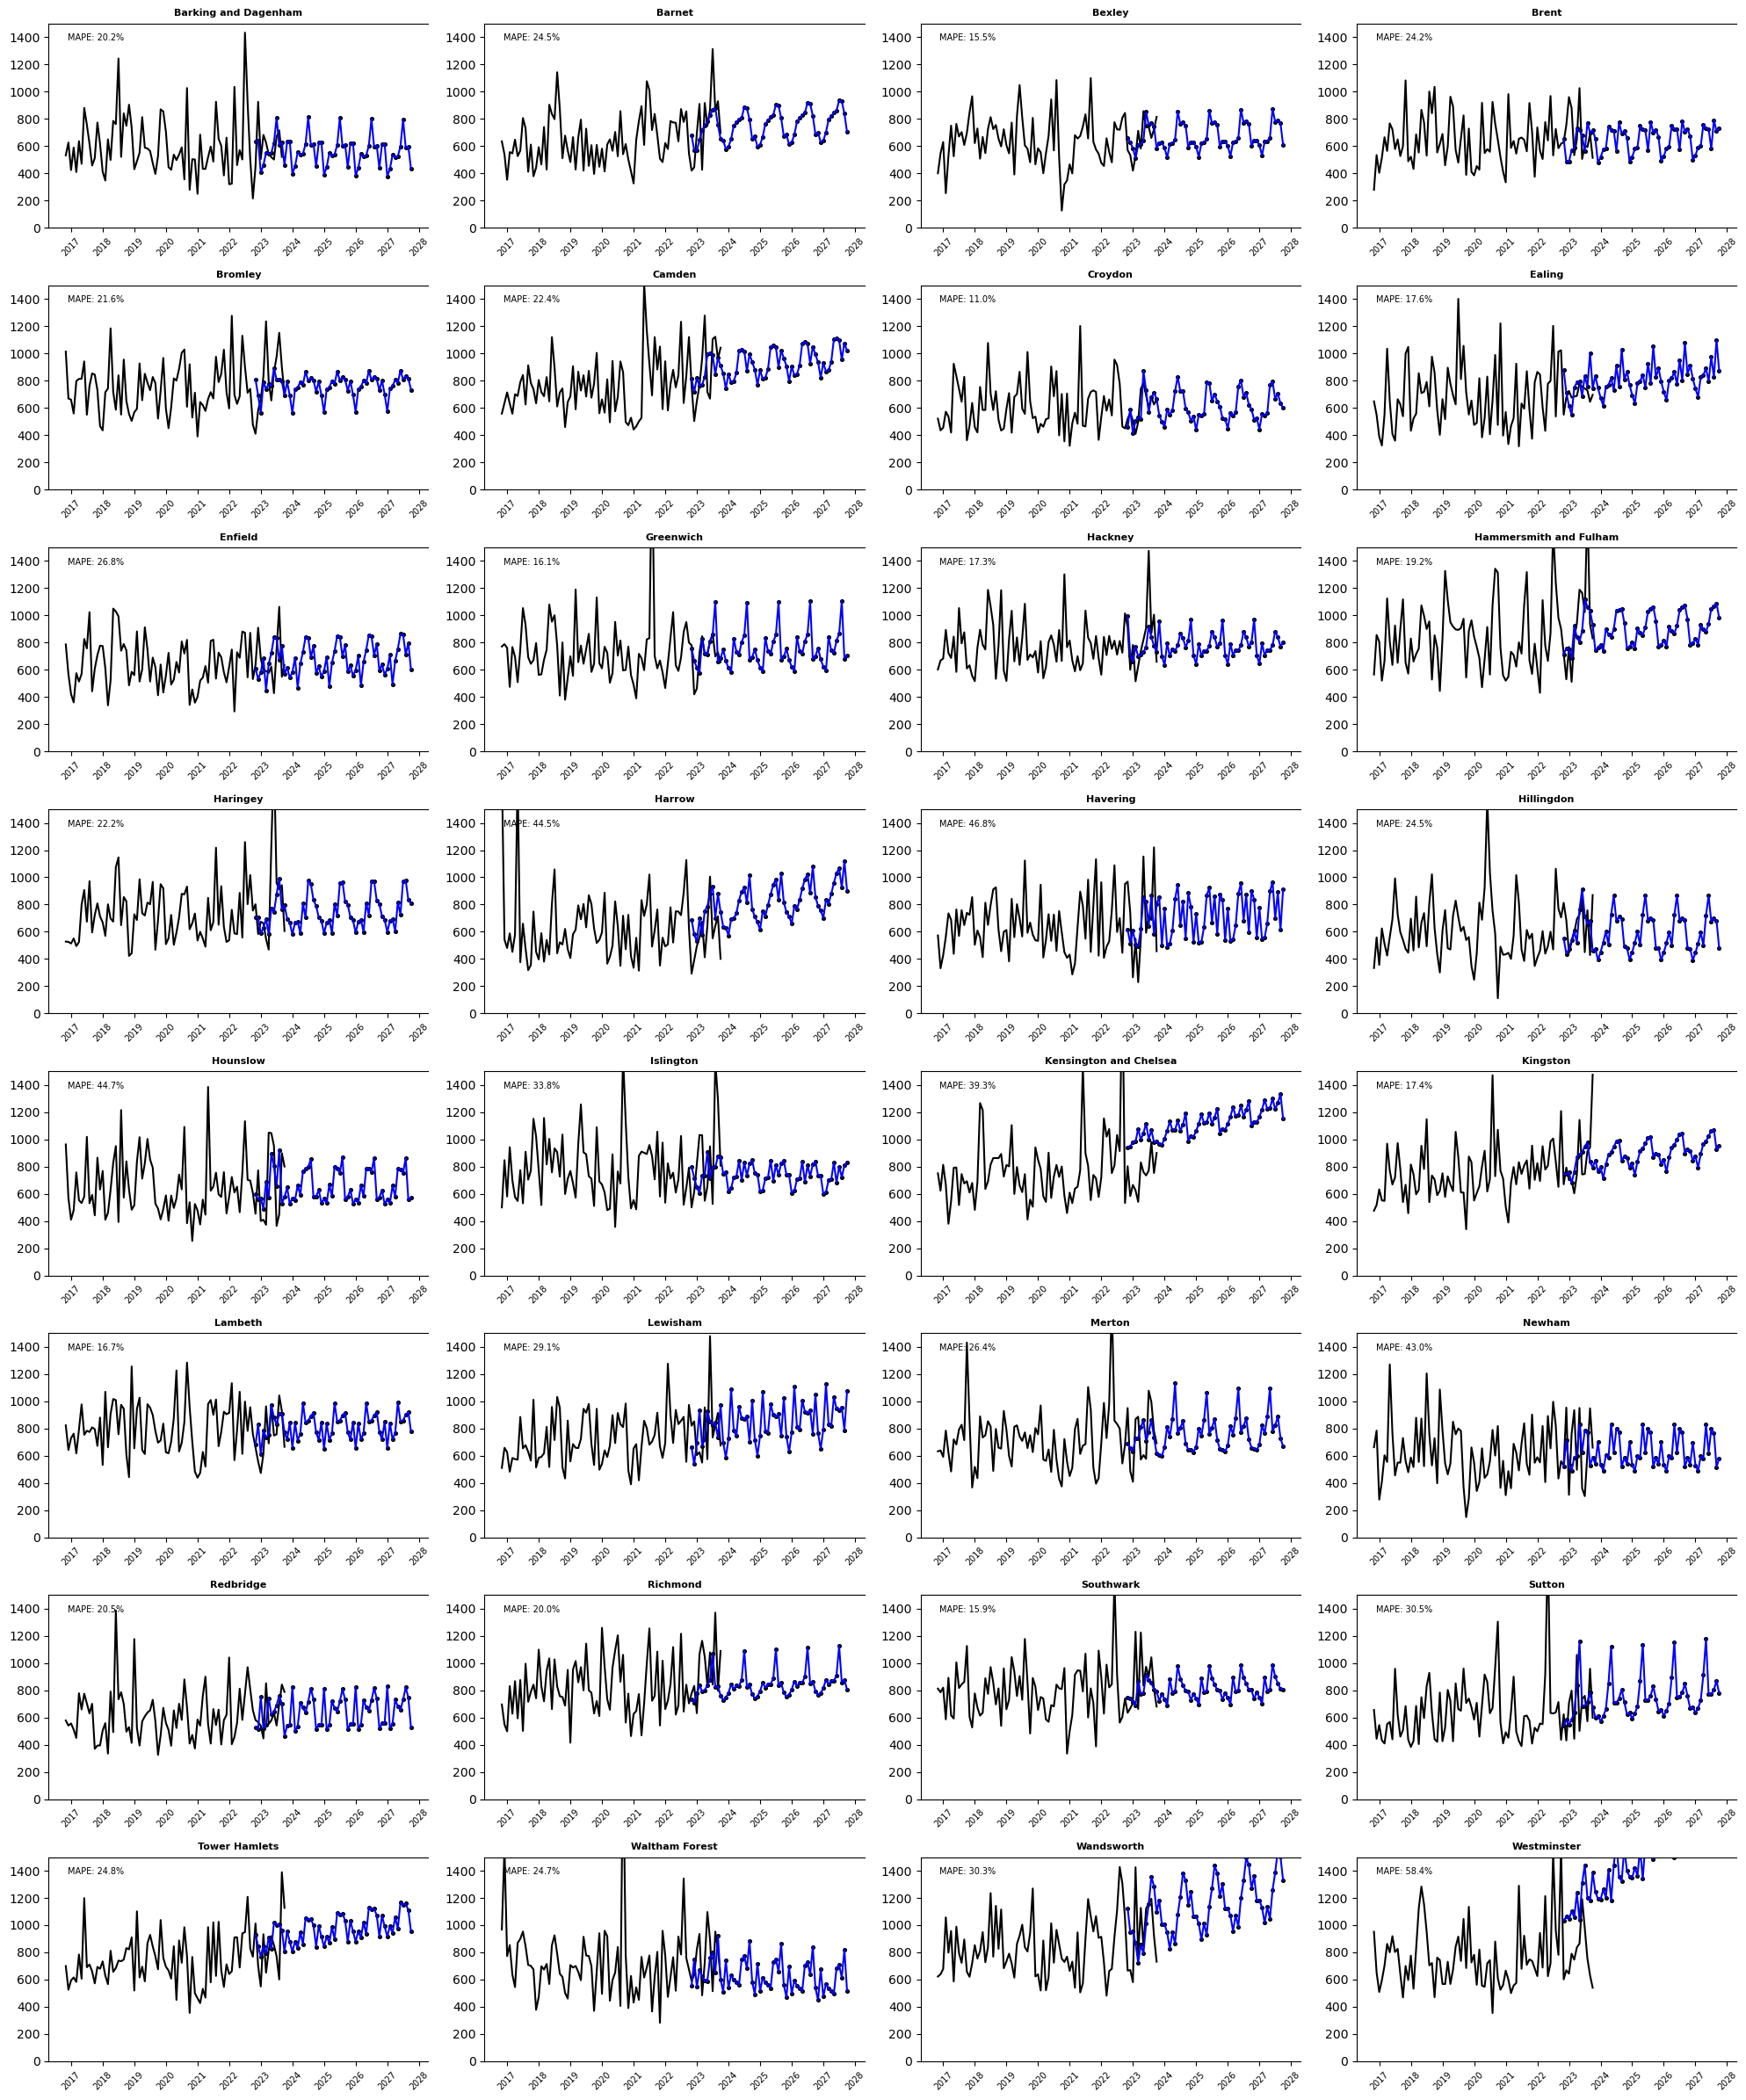

------------------------------
------ SARIMA QUARTERLY ------
------------------------------
SARIMA
quarterly average mape: 22.92205029678295


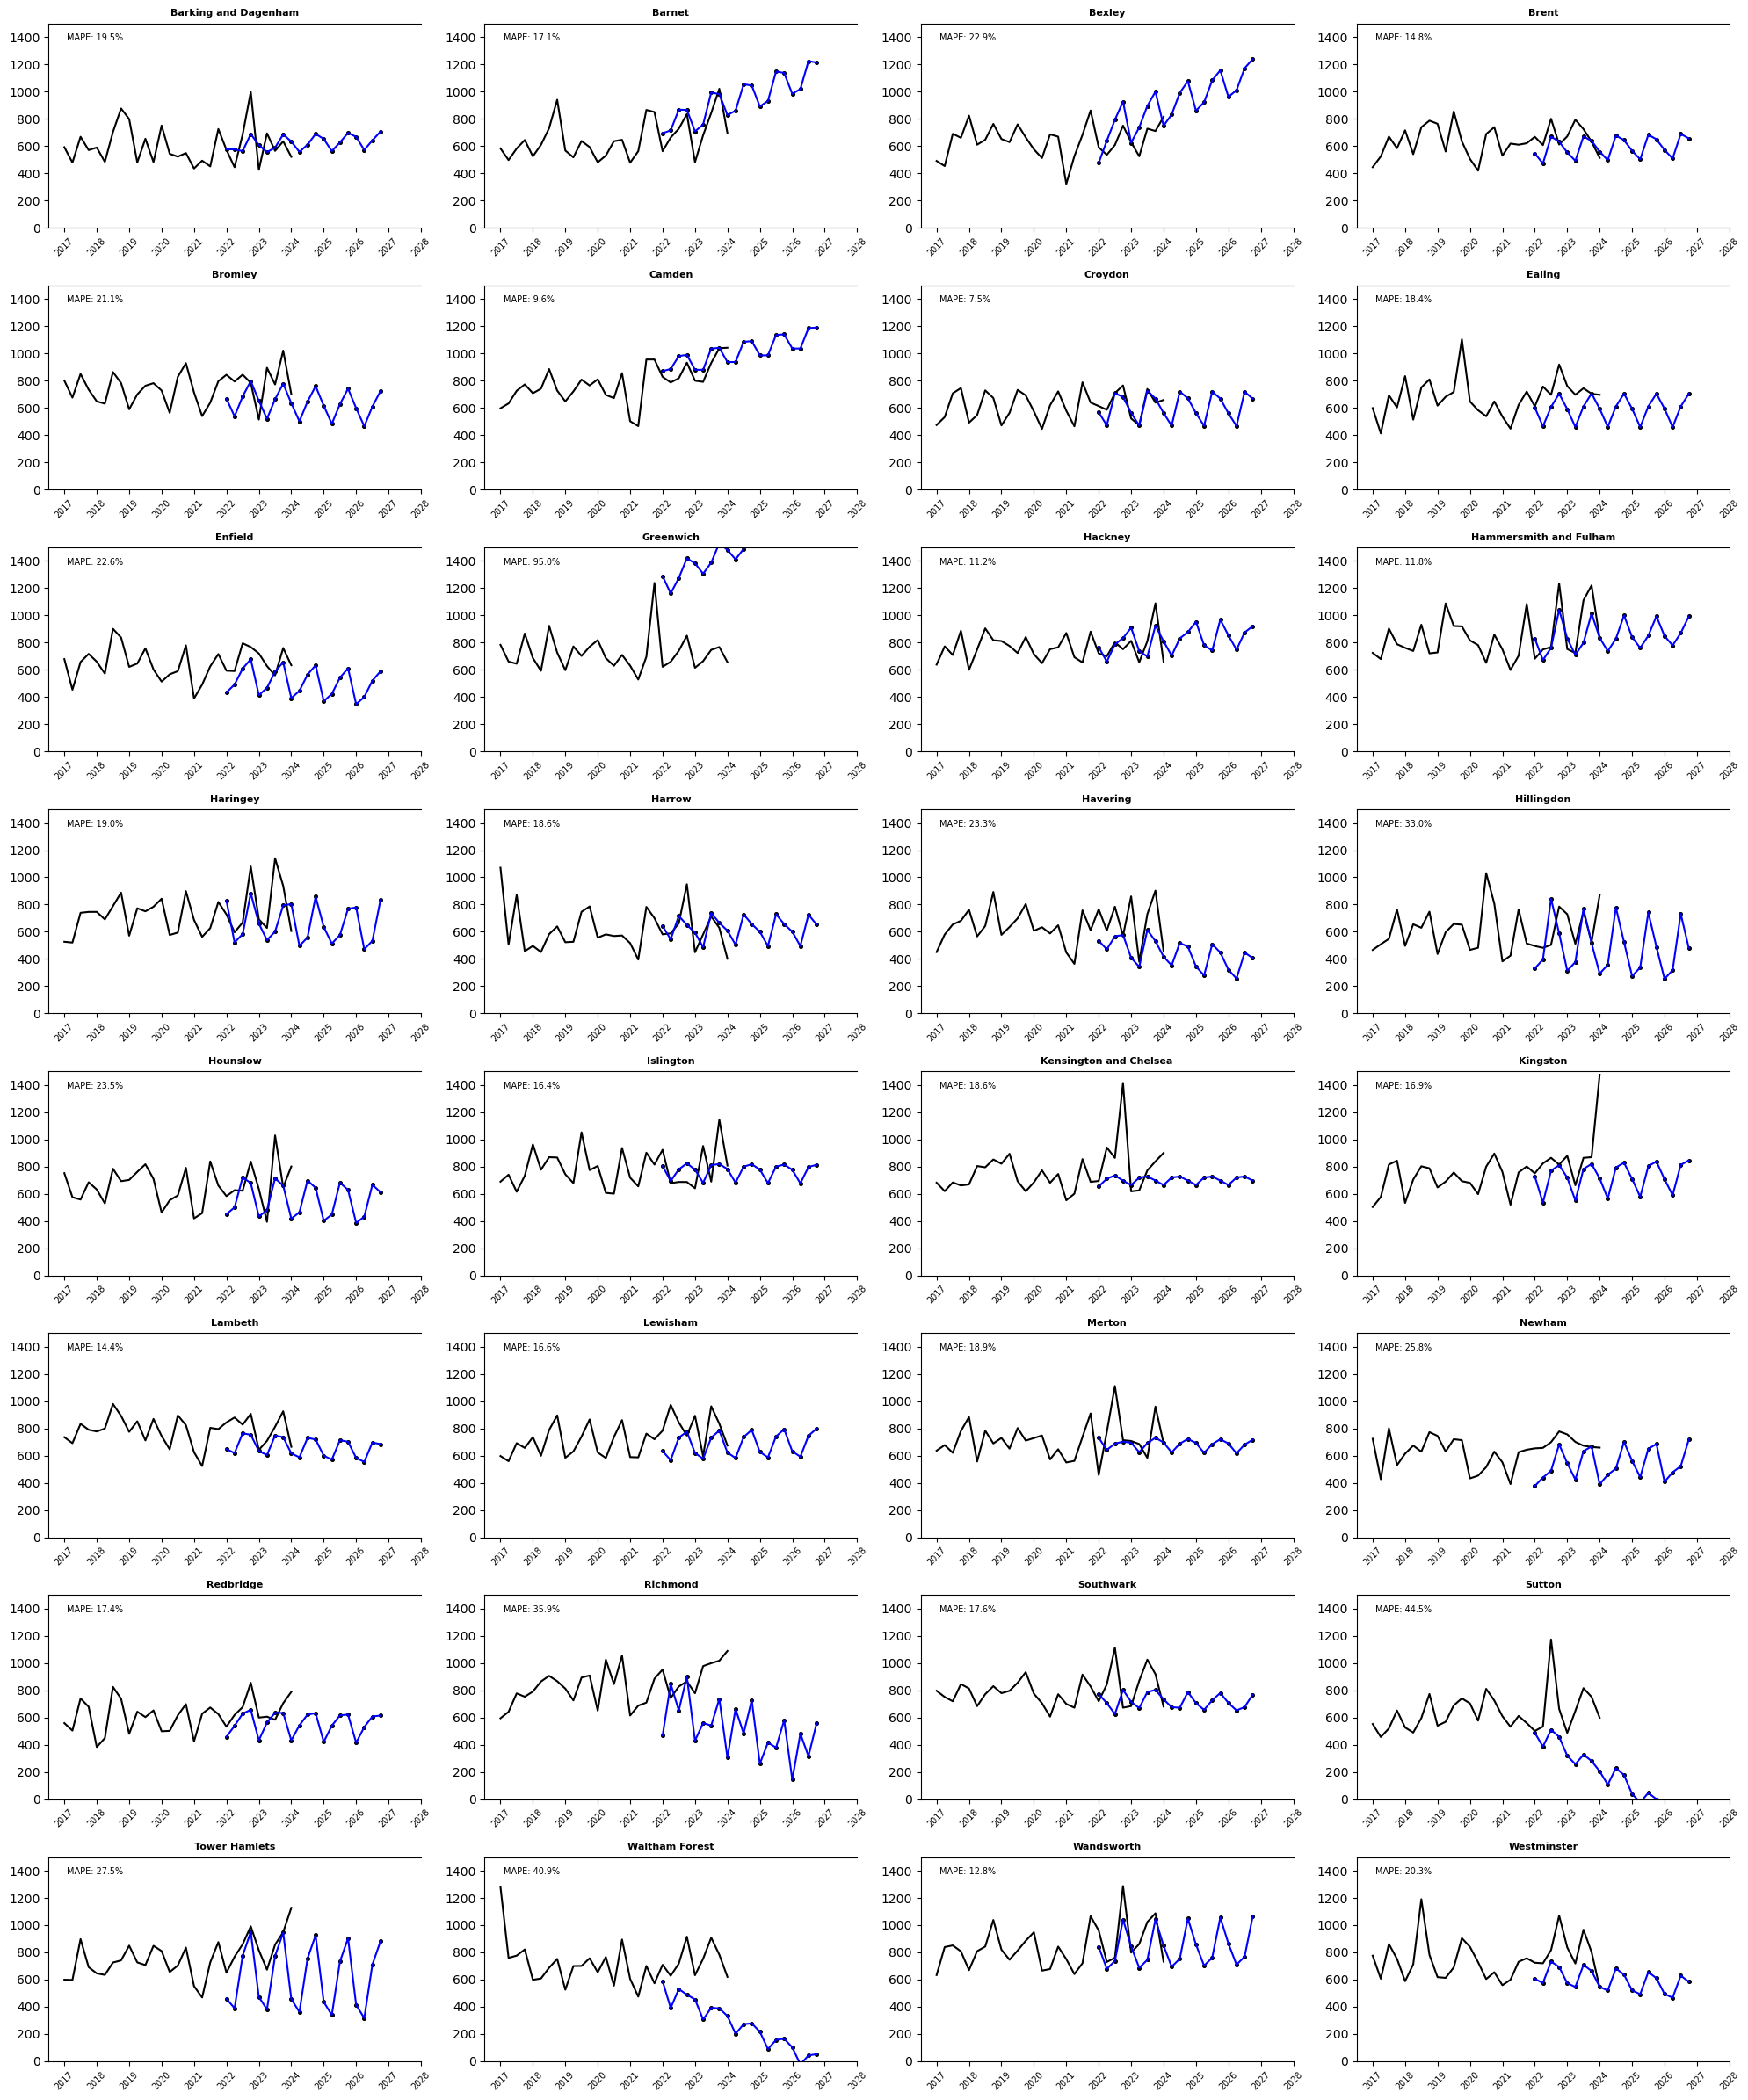



------------------------------
------ BAYESIAN MONTHLY ------
------------------------------
monthly average mape: 23.437922907926193


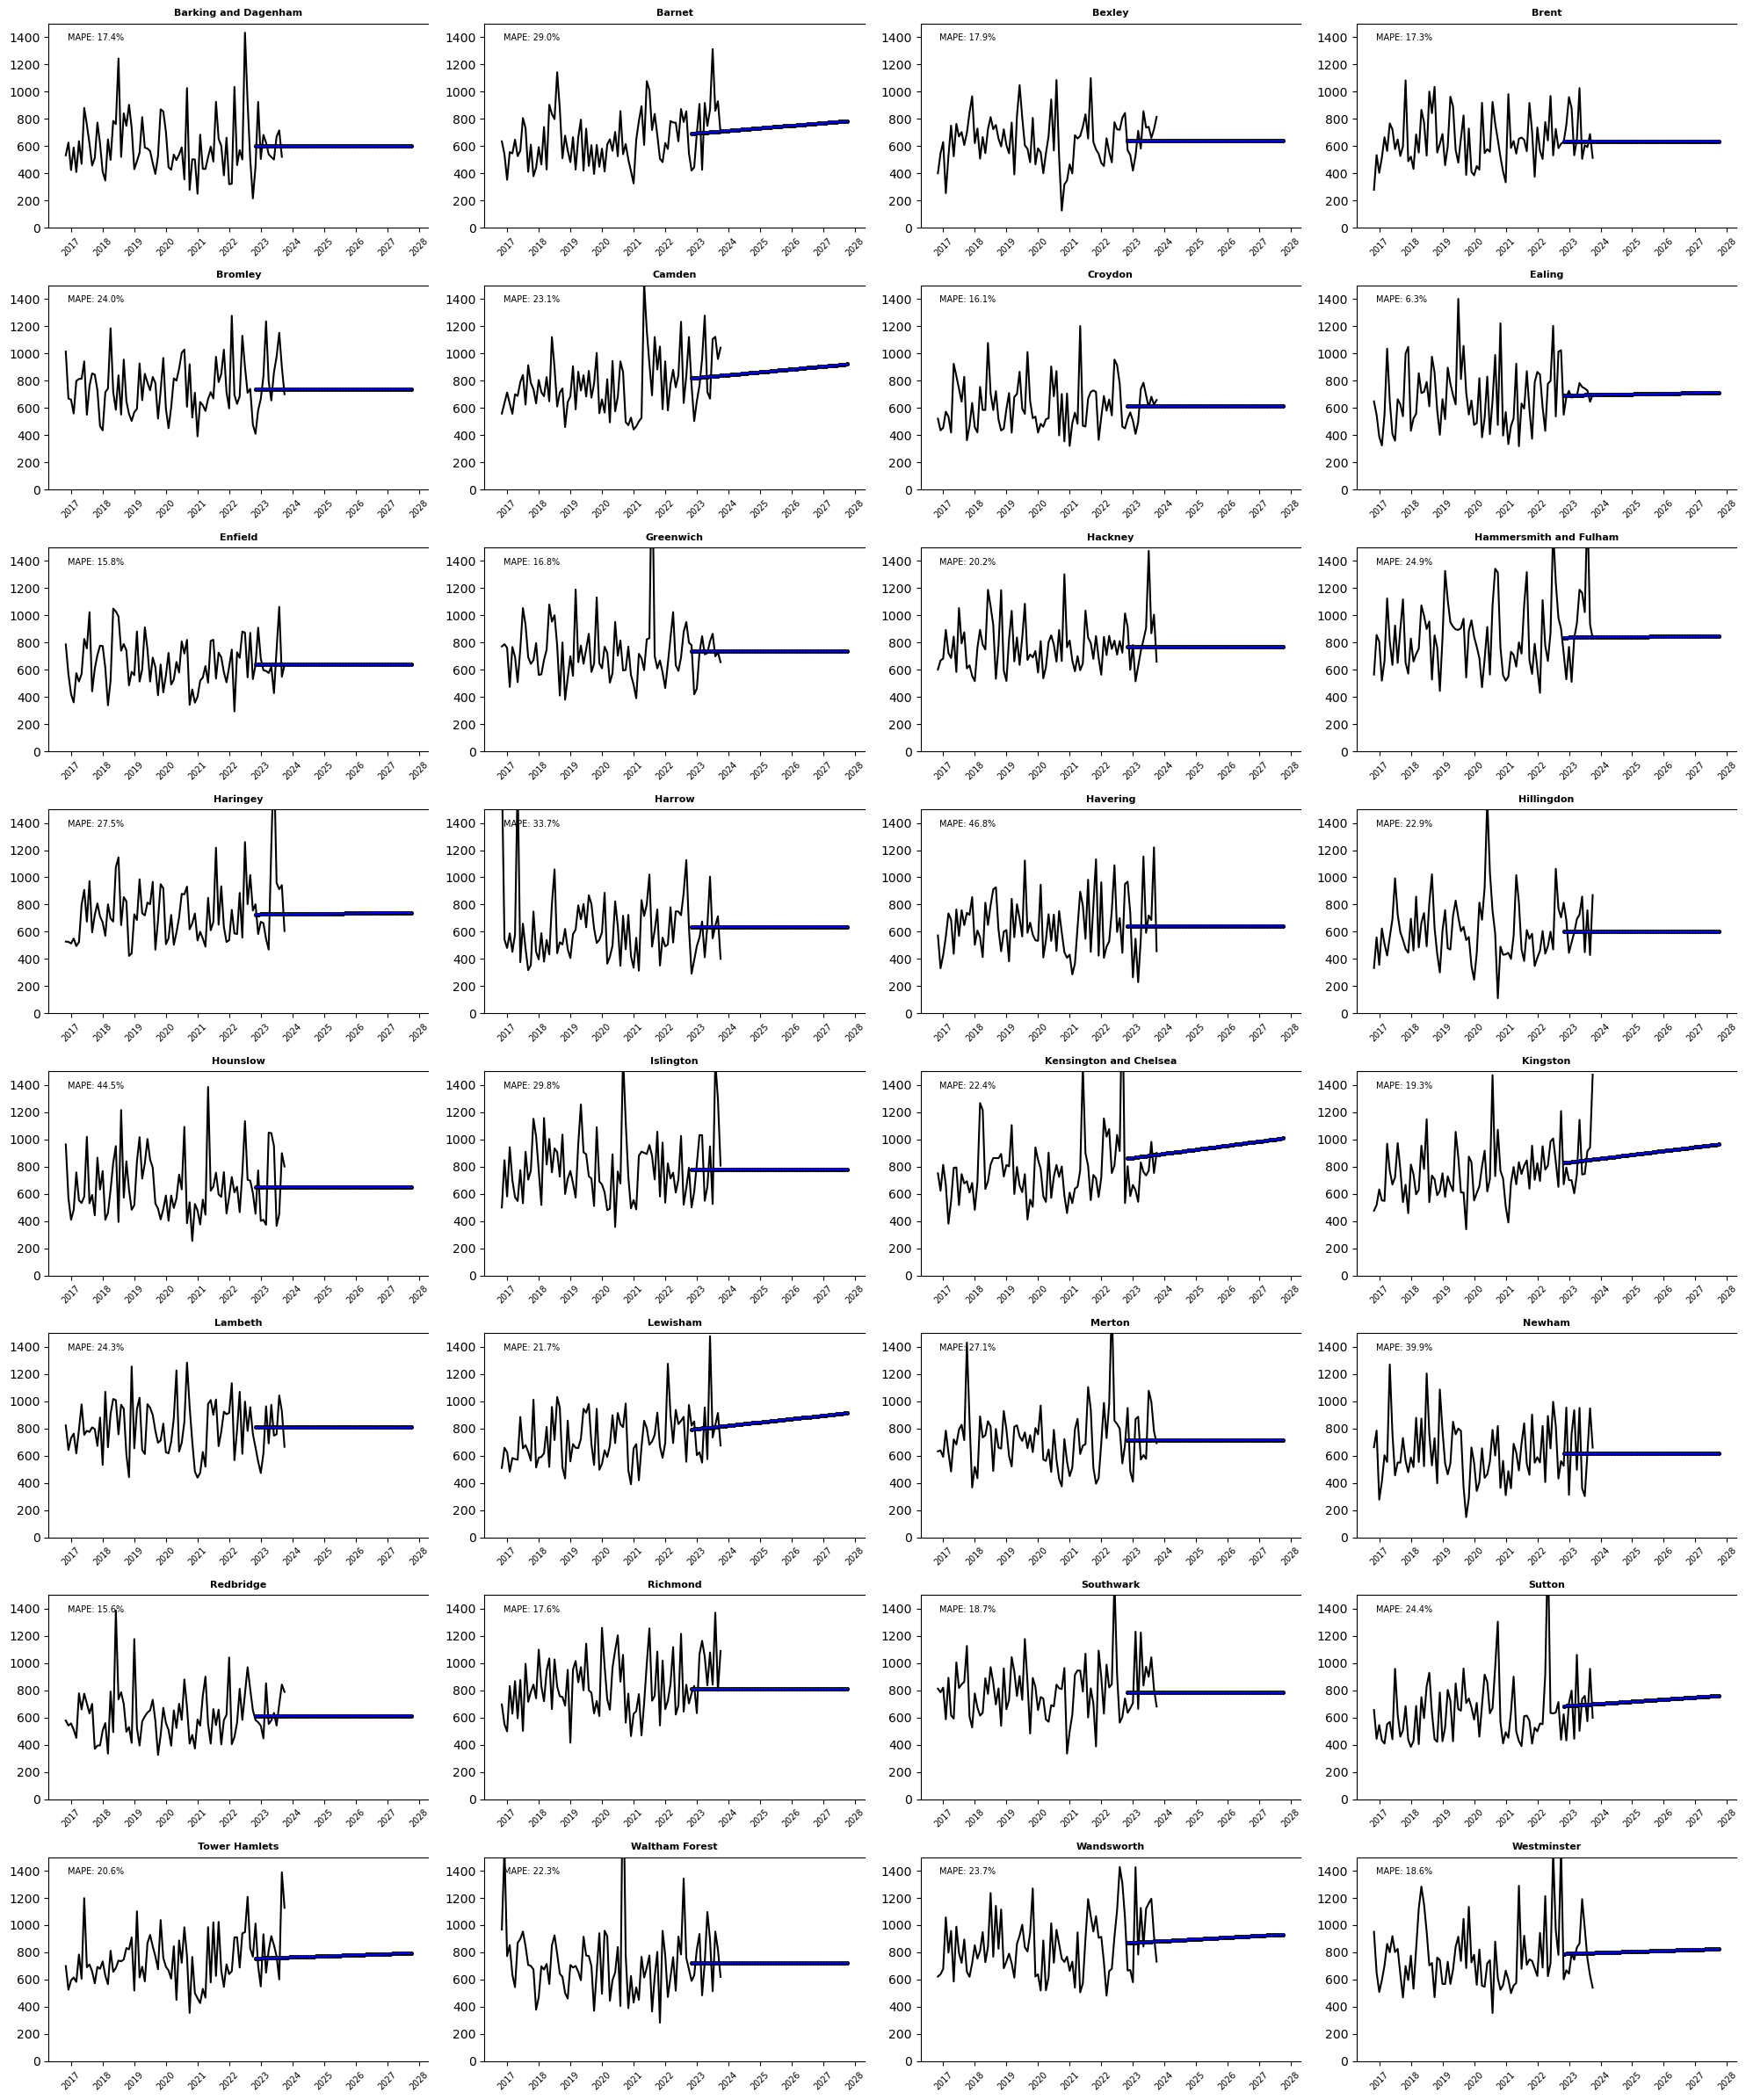

------------------------------
----- BAYESIAN QUARTERLY -----
------------------------------
quarterly average mape: 15.98986376706431


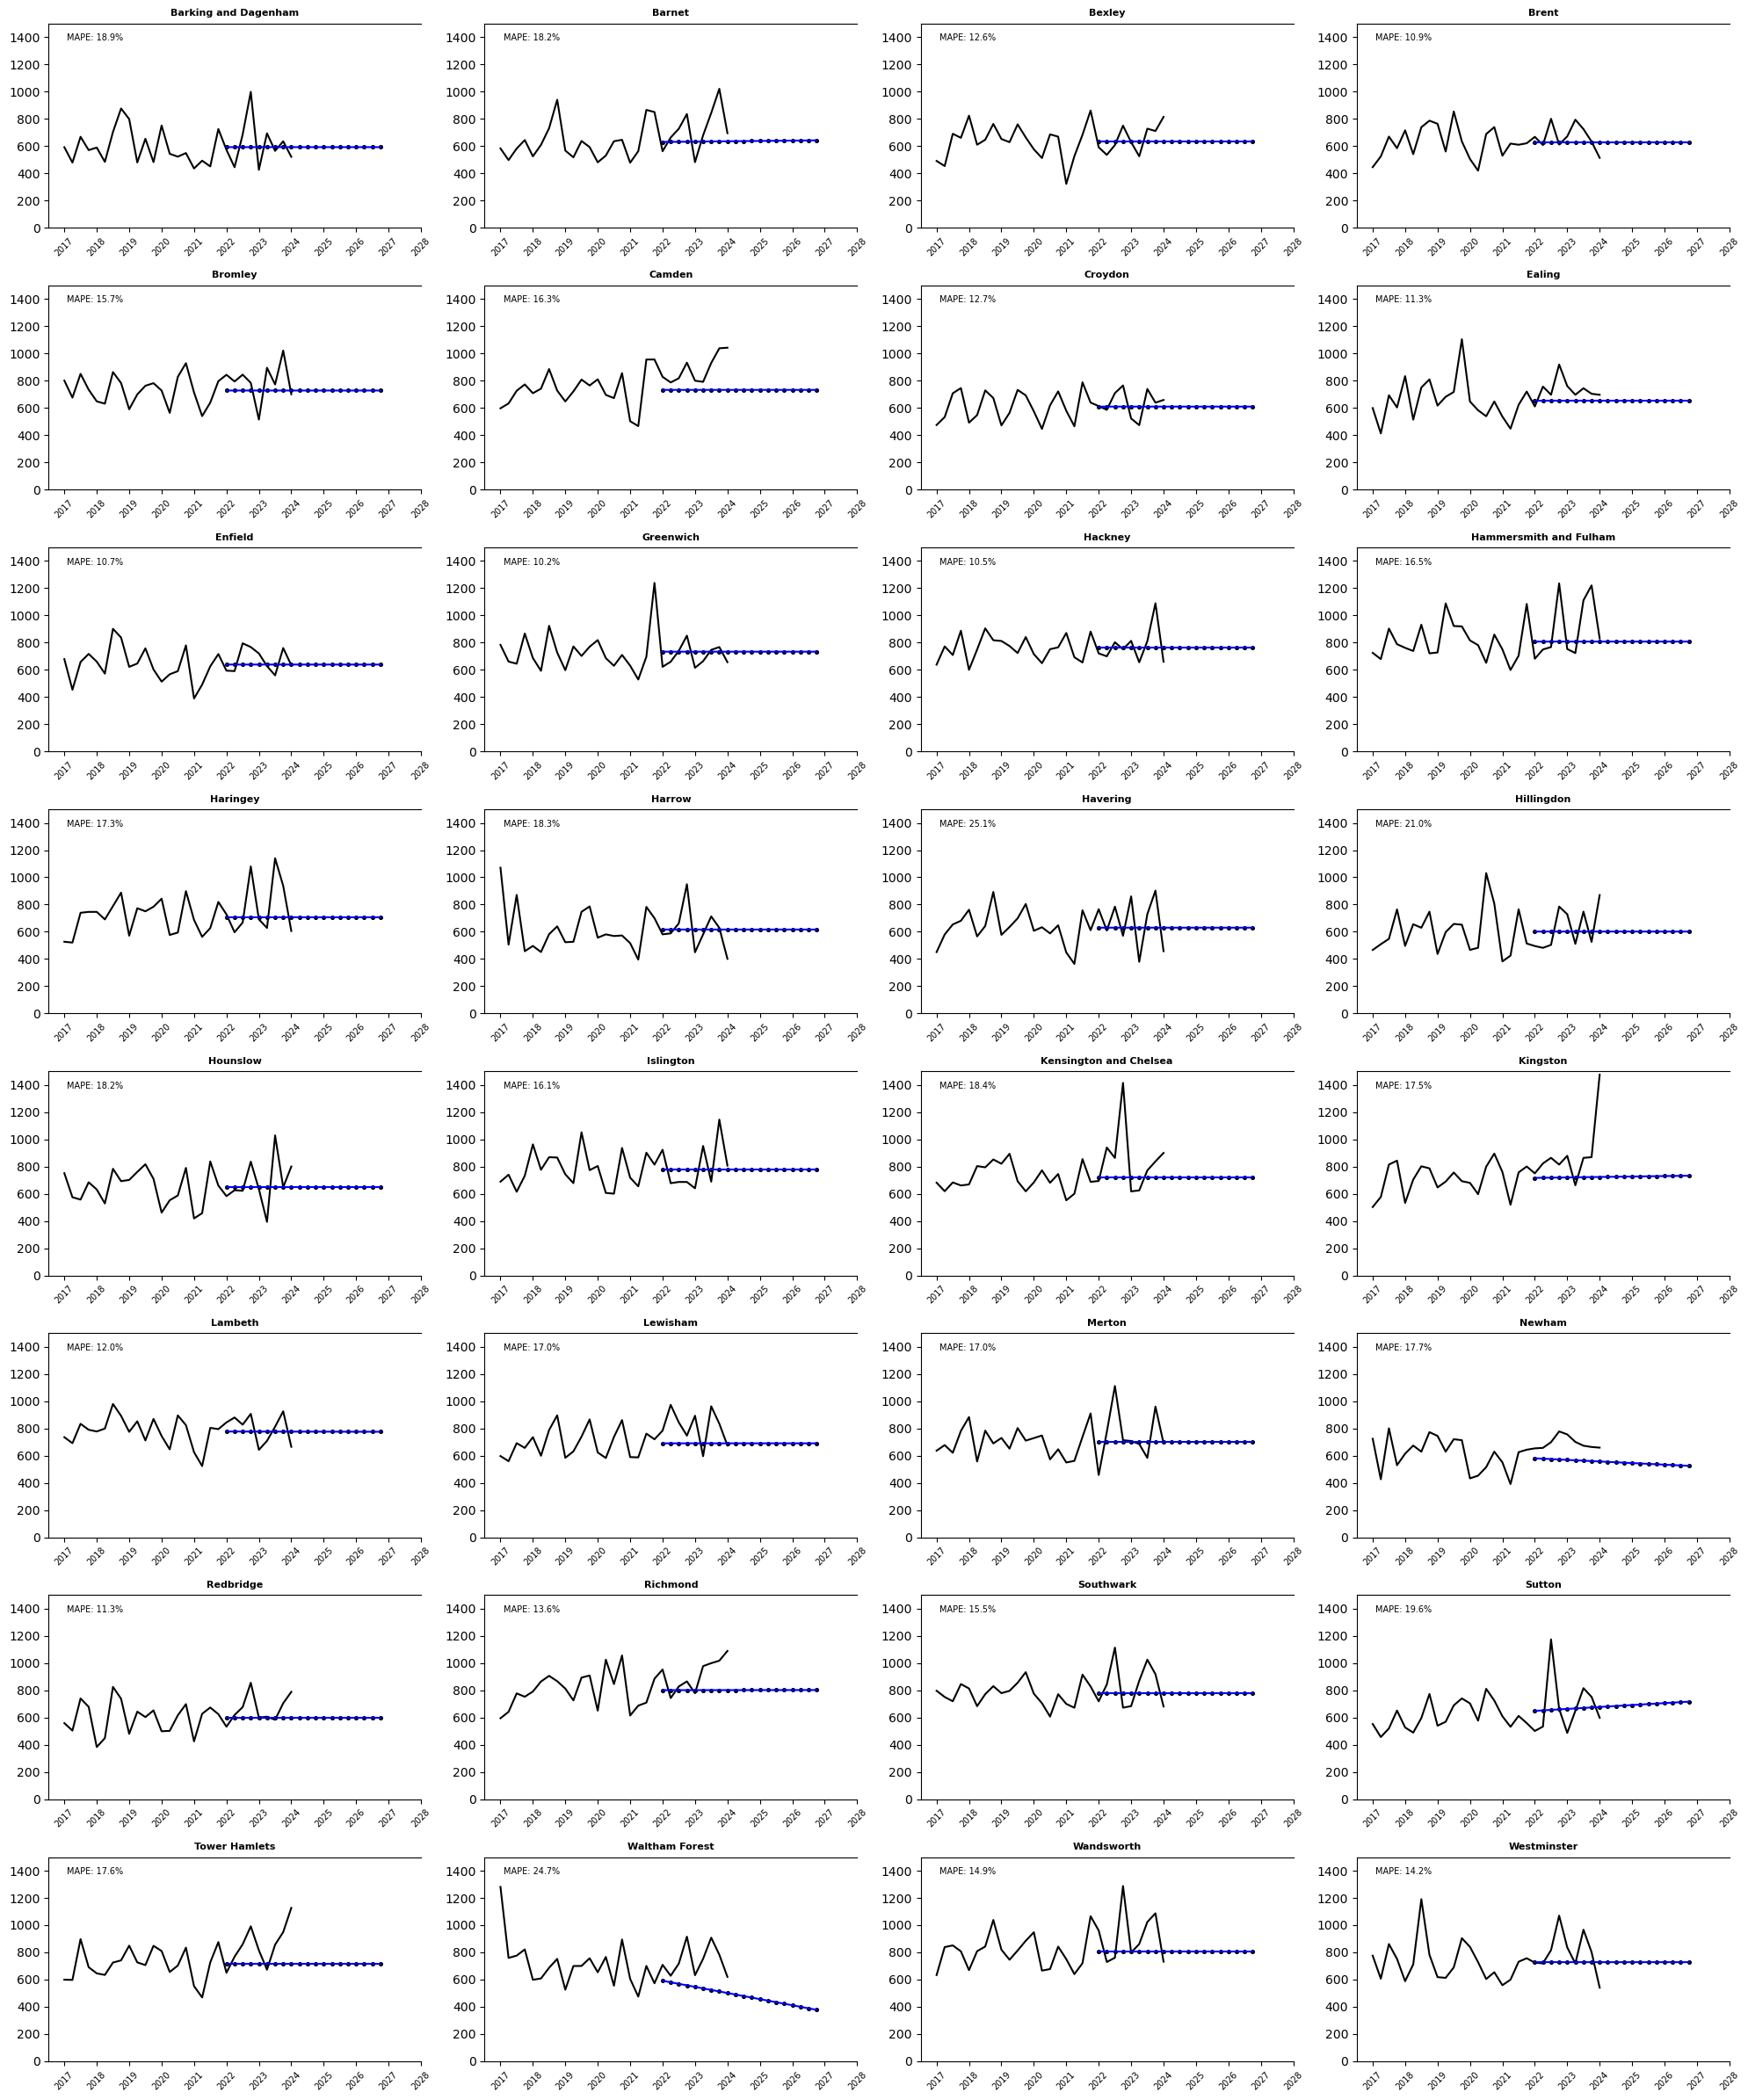

-------------------------------
------- BAYESIAN YEARLY -------
-------------------------------
yearly average mape: 12.16117208908418


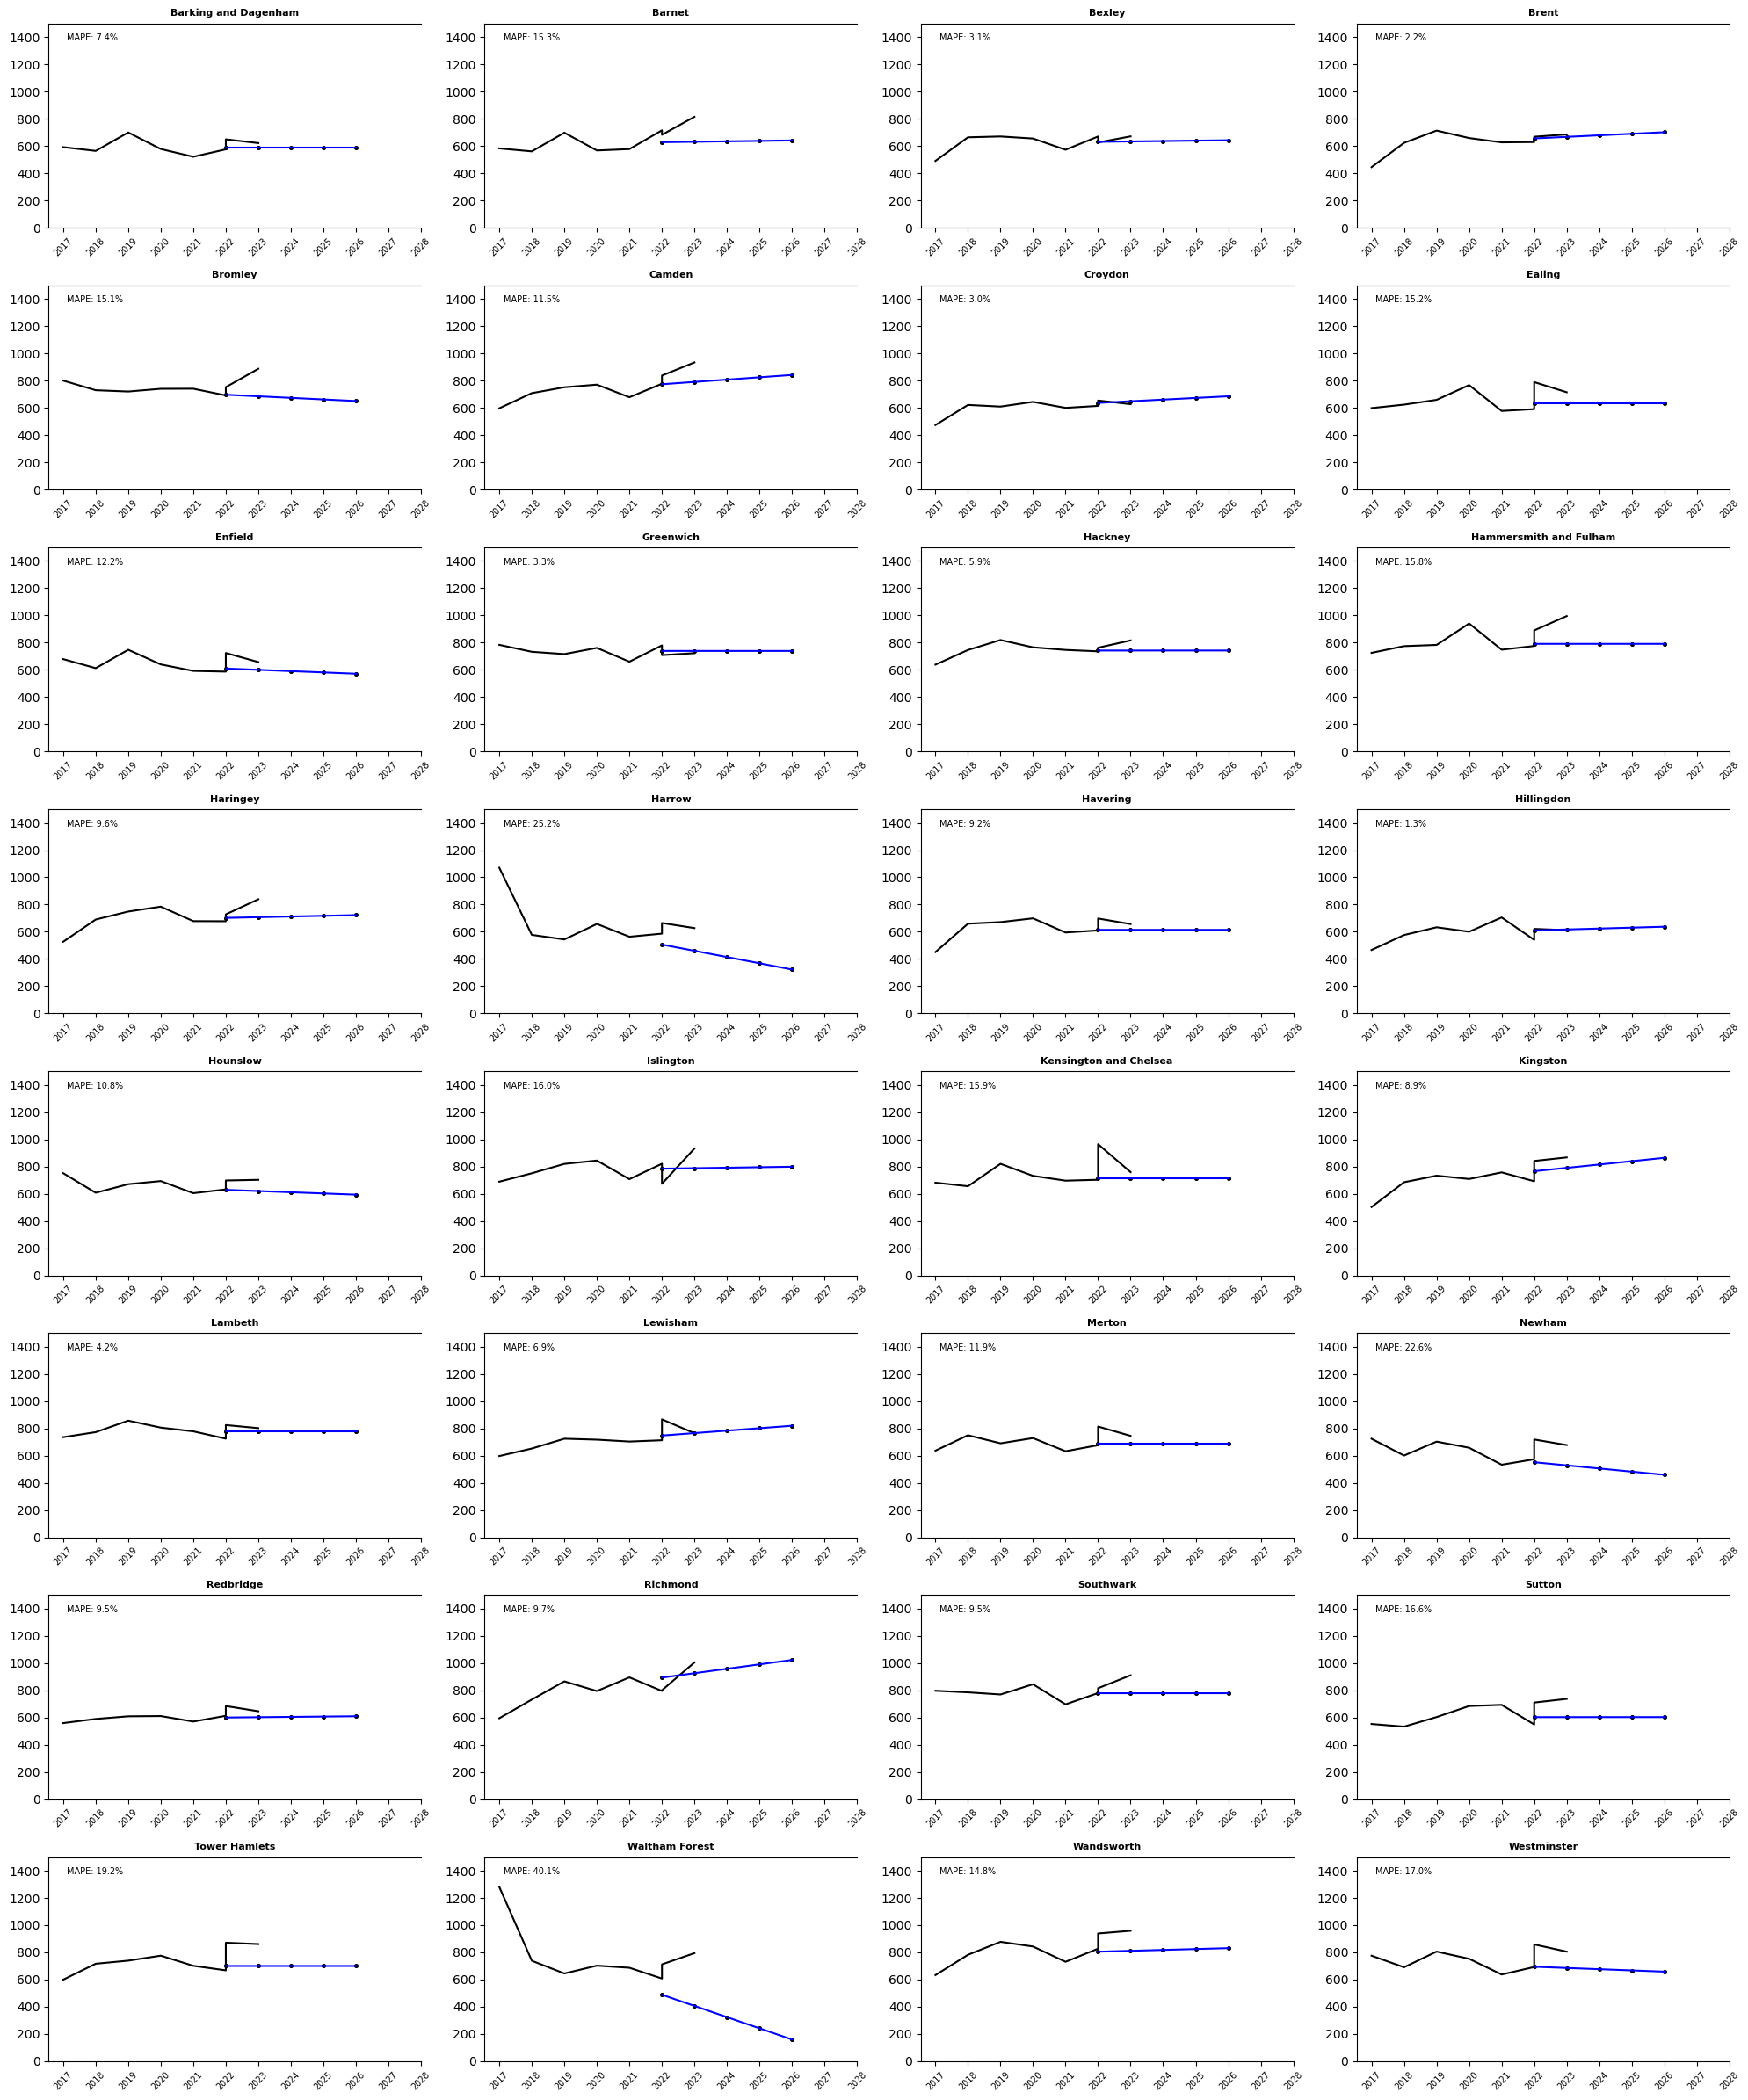




------------------------------
------- COVID ADJUSTED -------
------- SARIMA MONTHLY -------
------------------------------
monthly average mape: 30.07287876234534


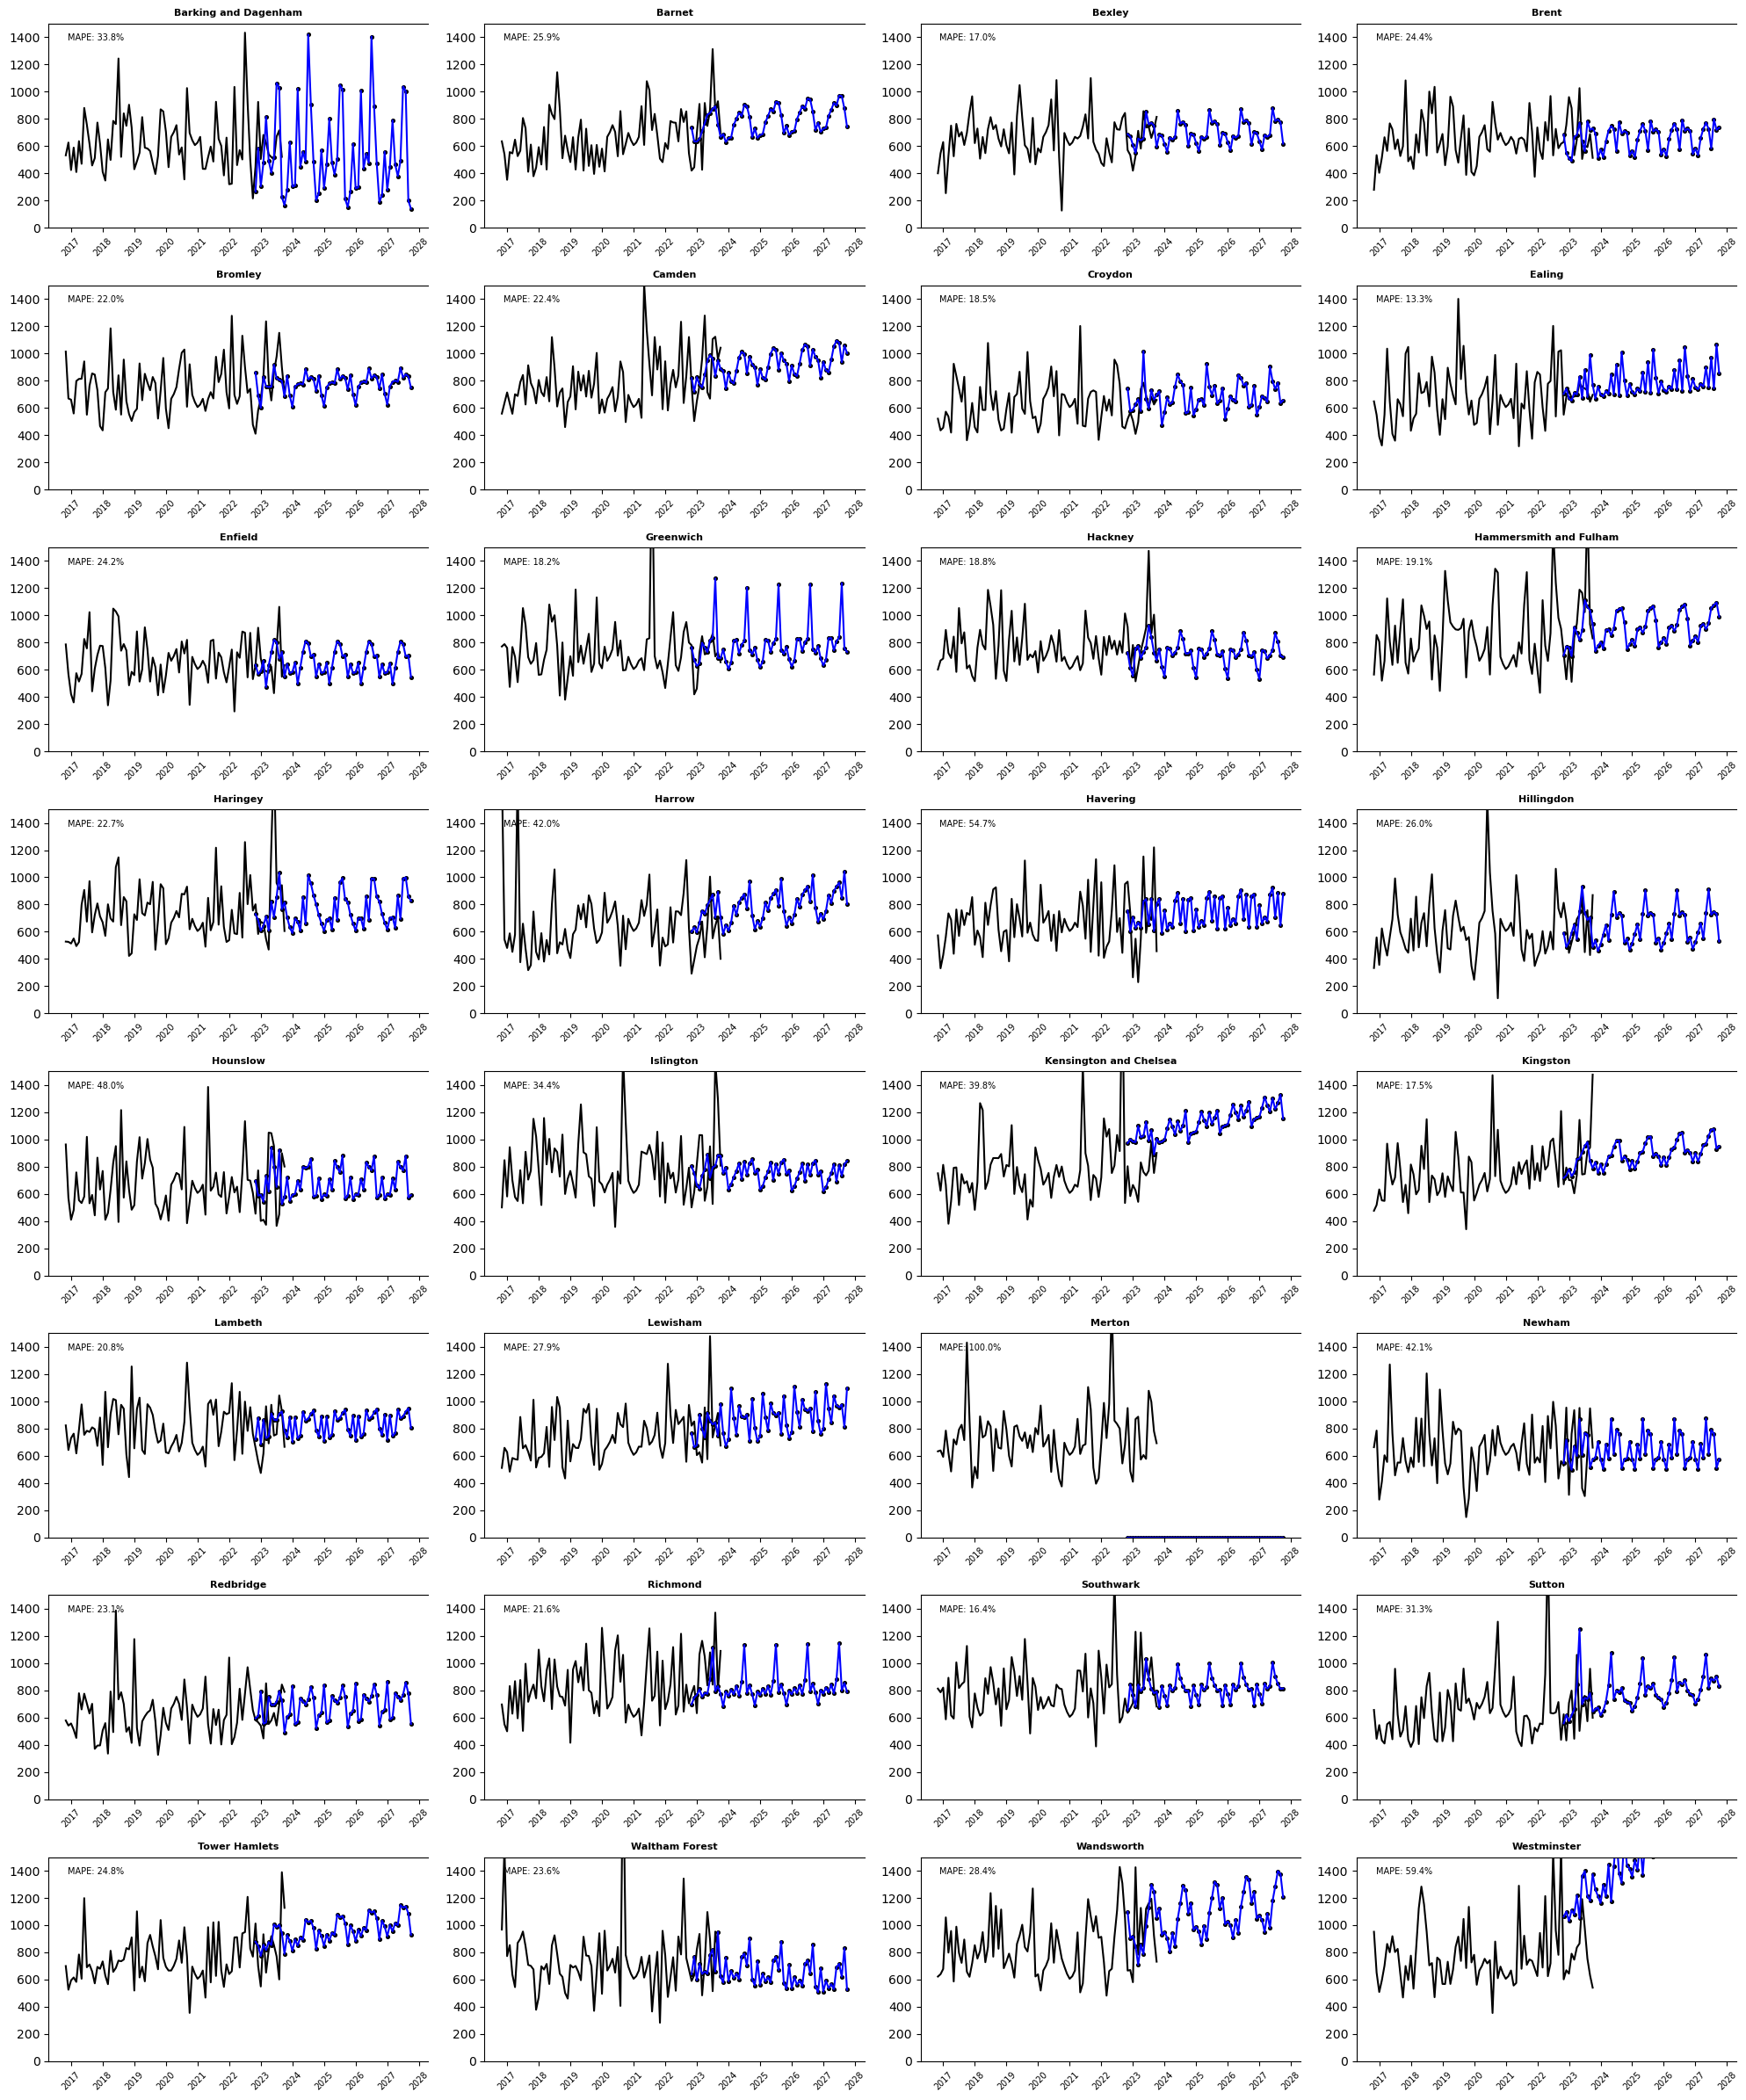

------------------------------
------- COVID ADJUSTED -------
------ SARIMA QUARTERLY ------
------------------------------
quarterly average mape: 19.71053633458799


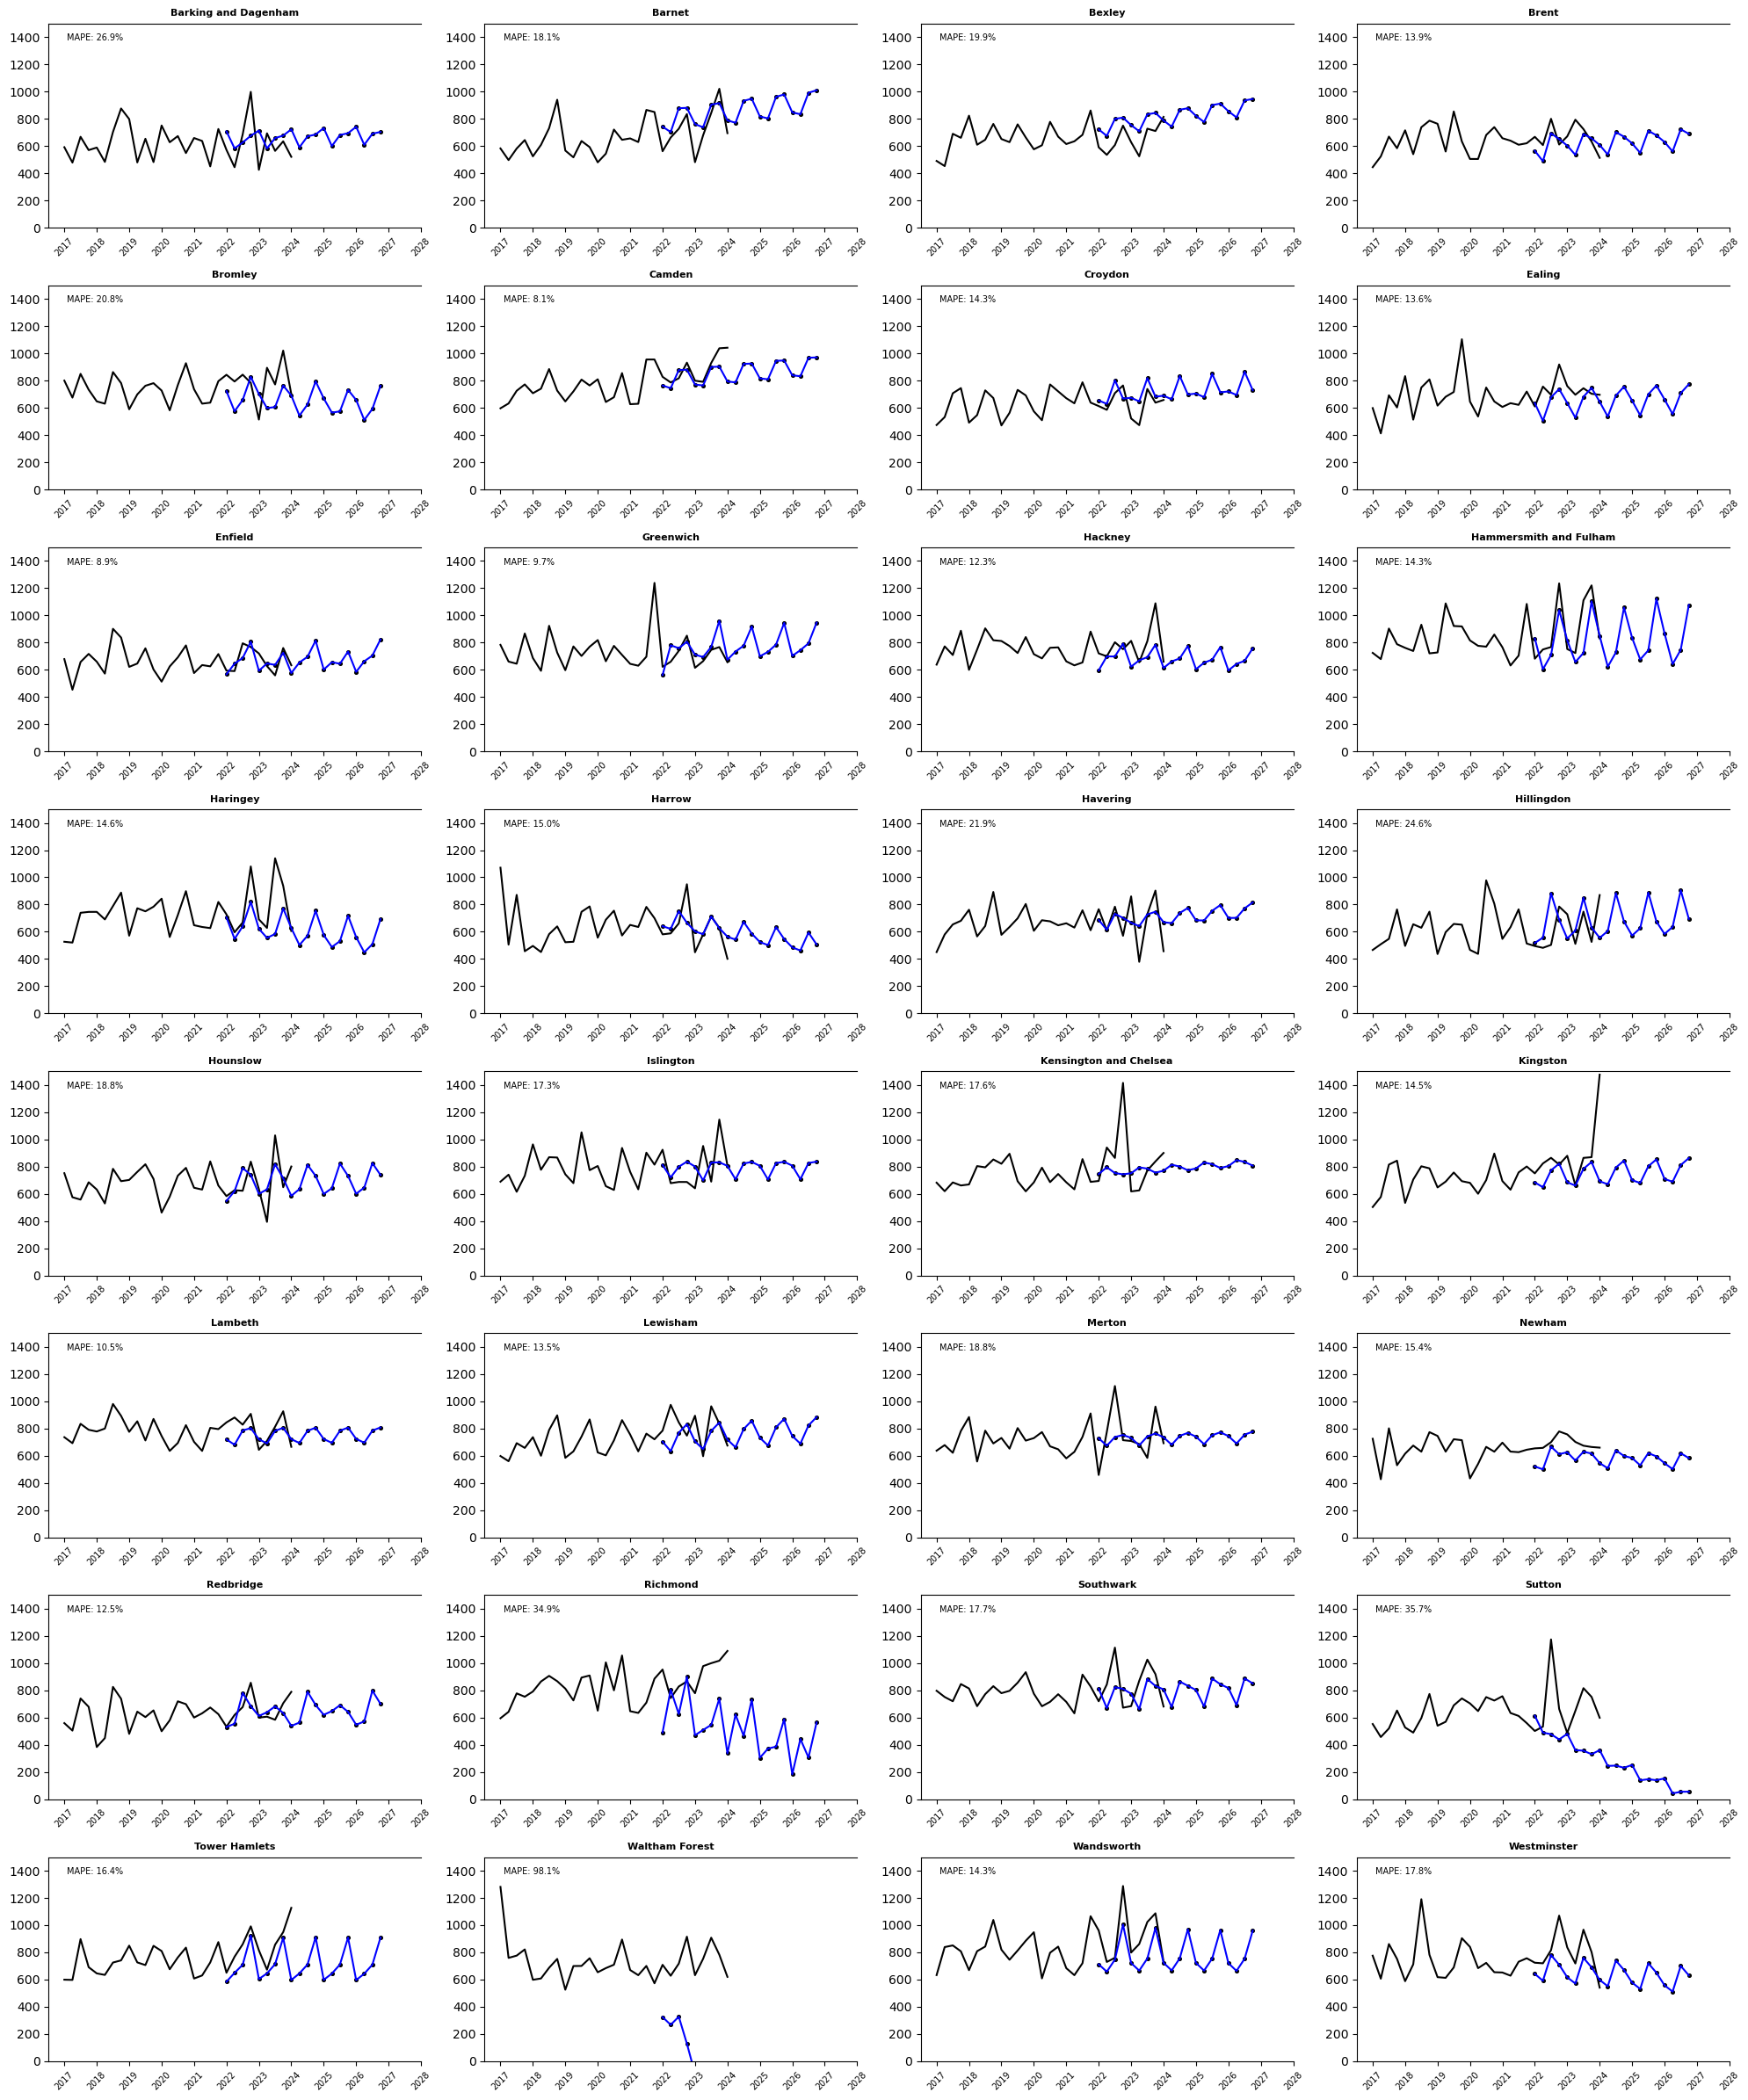



------------------------------
------- COVID ADJUSTED -------
------ BAYESIAN MONTHLY ------
------------------------------
monthly average mape: 24.22513122989458


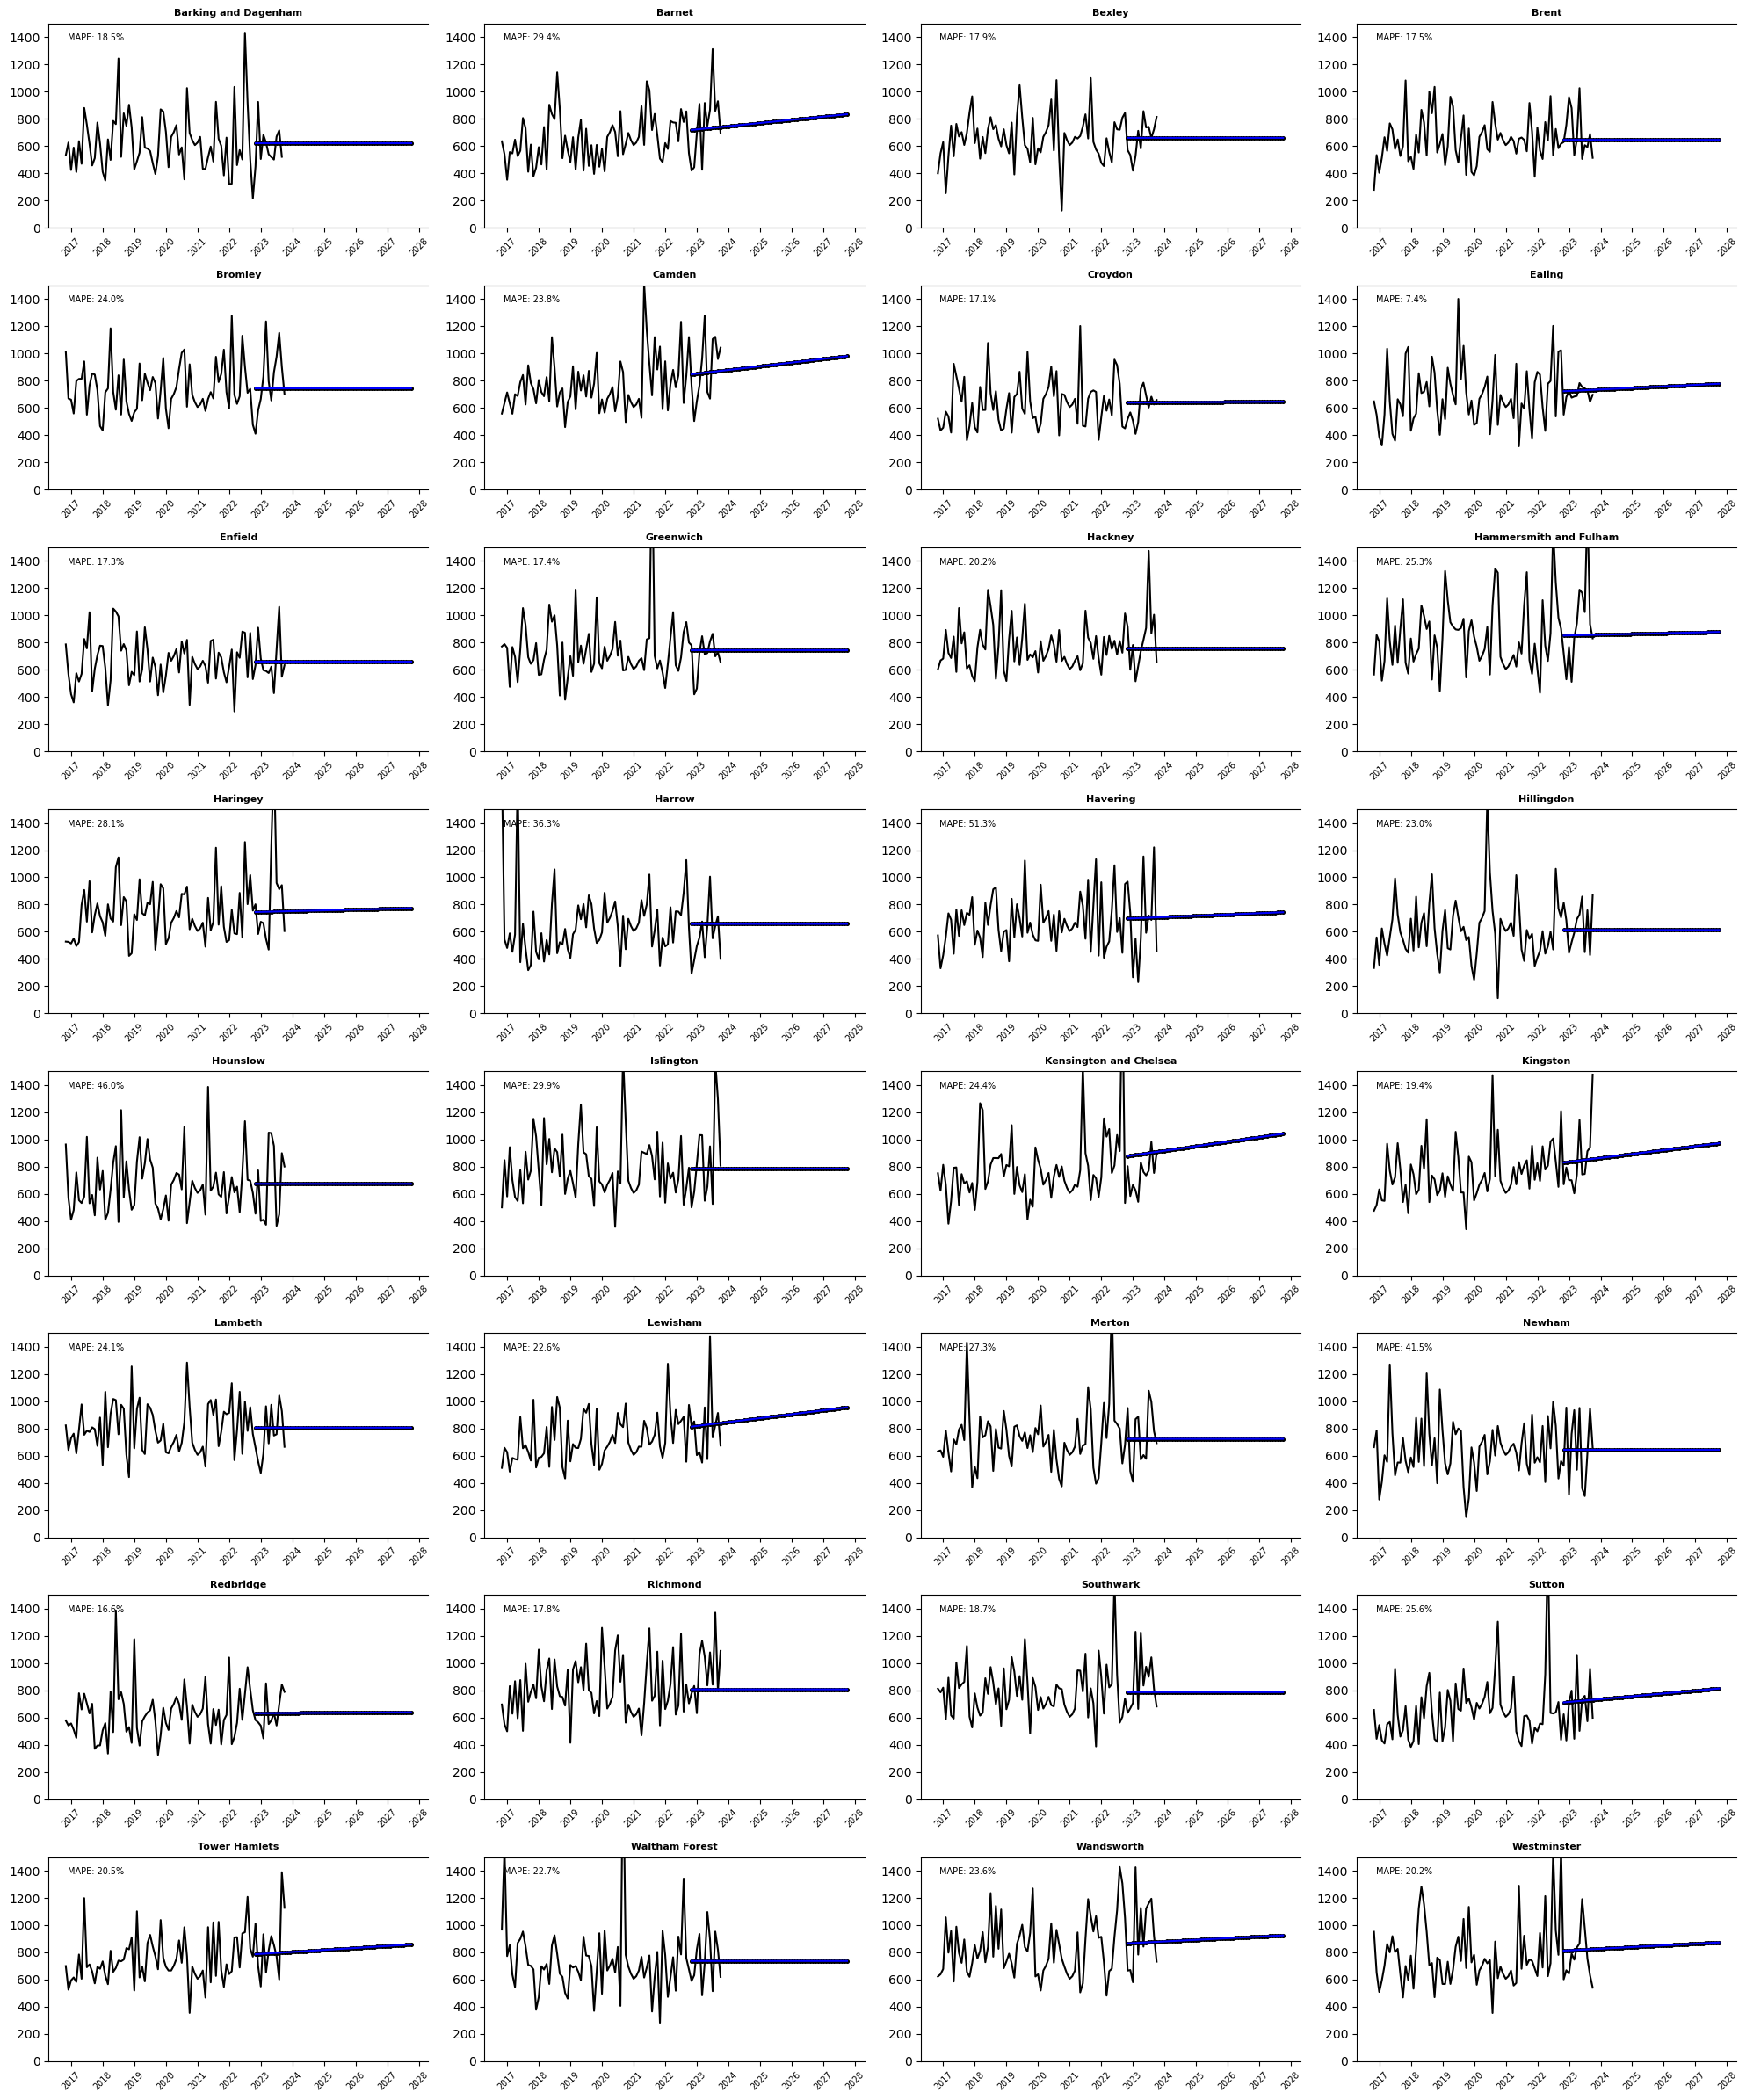

------------------------------
------- COVID ADJUSTED -------
----- BAYESIAN QUARTERLY -----
------------------------------
quarterly average mape: 15.5676669824019


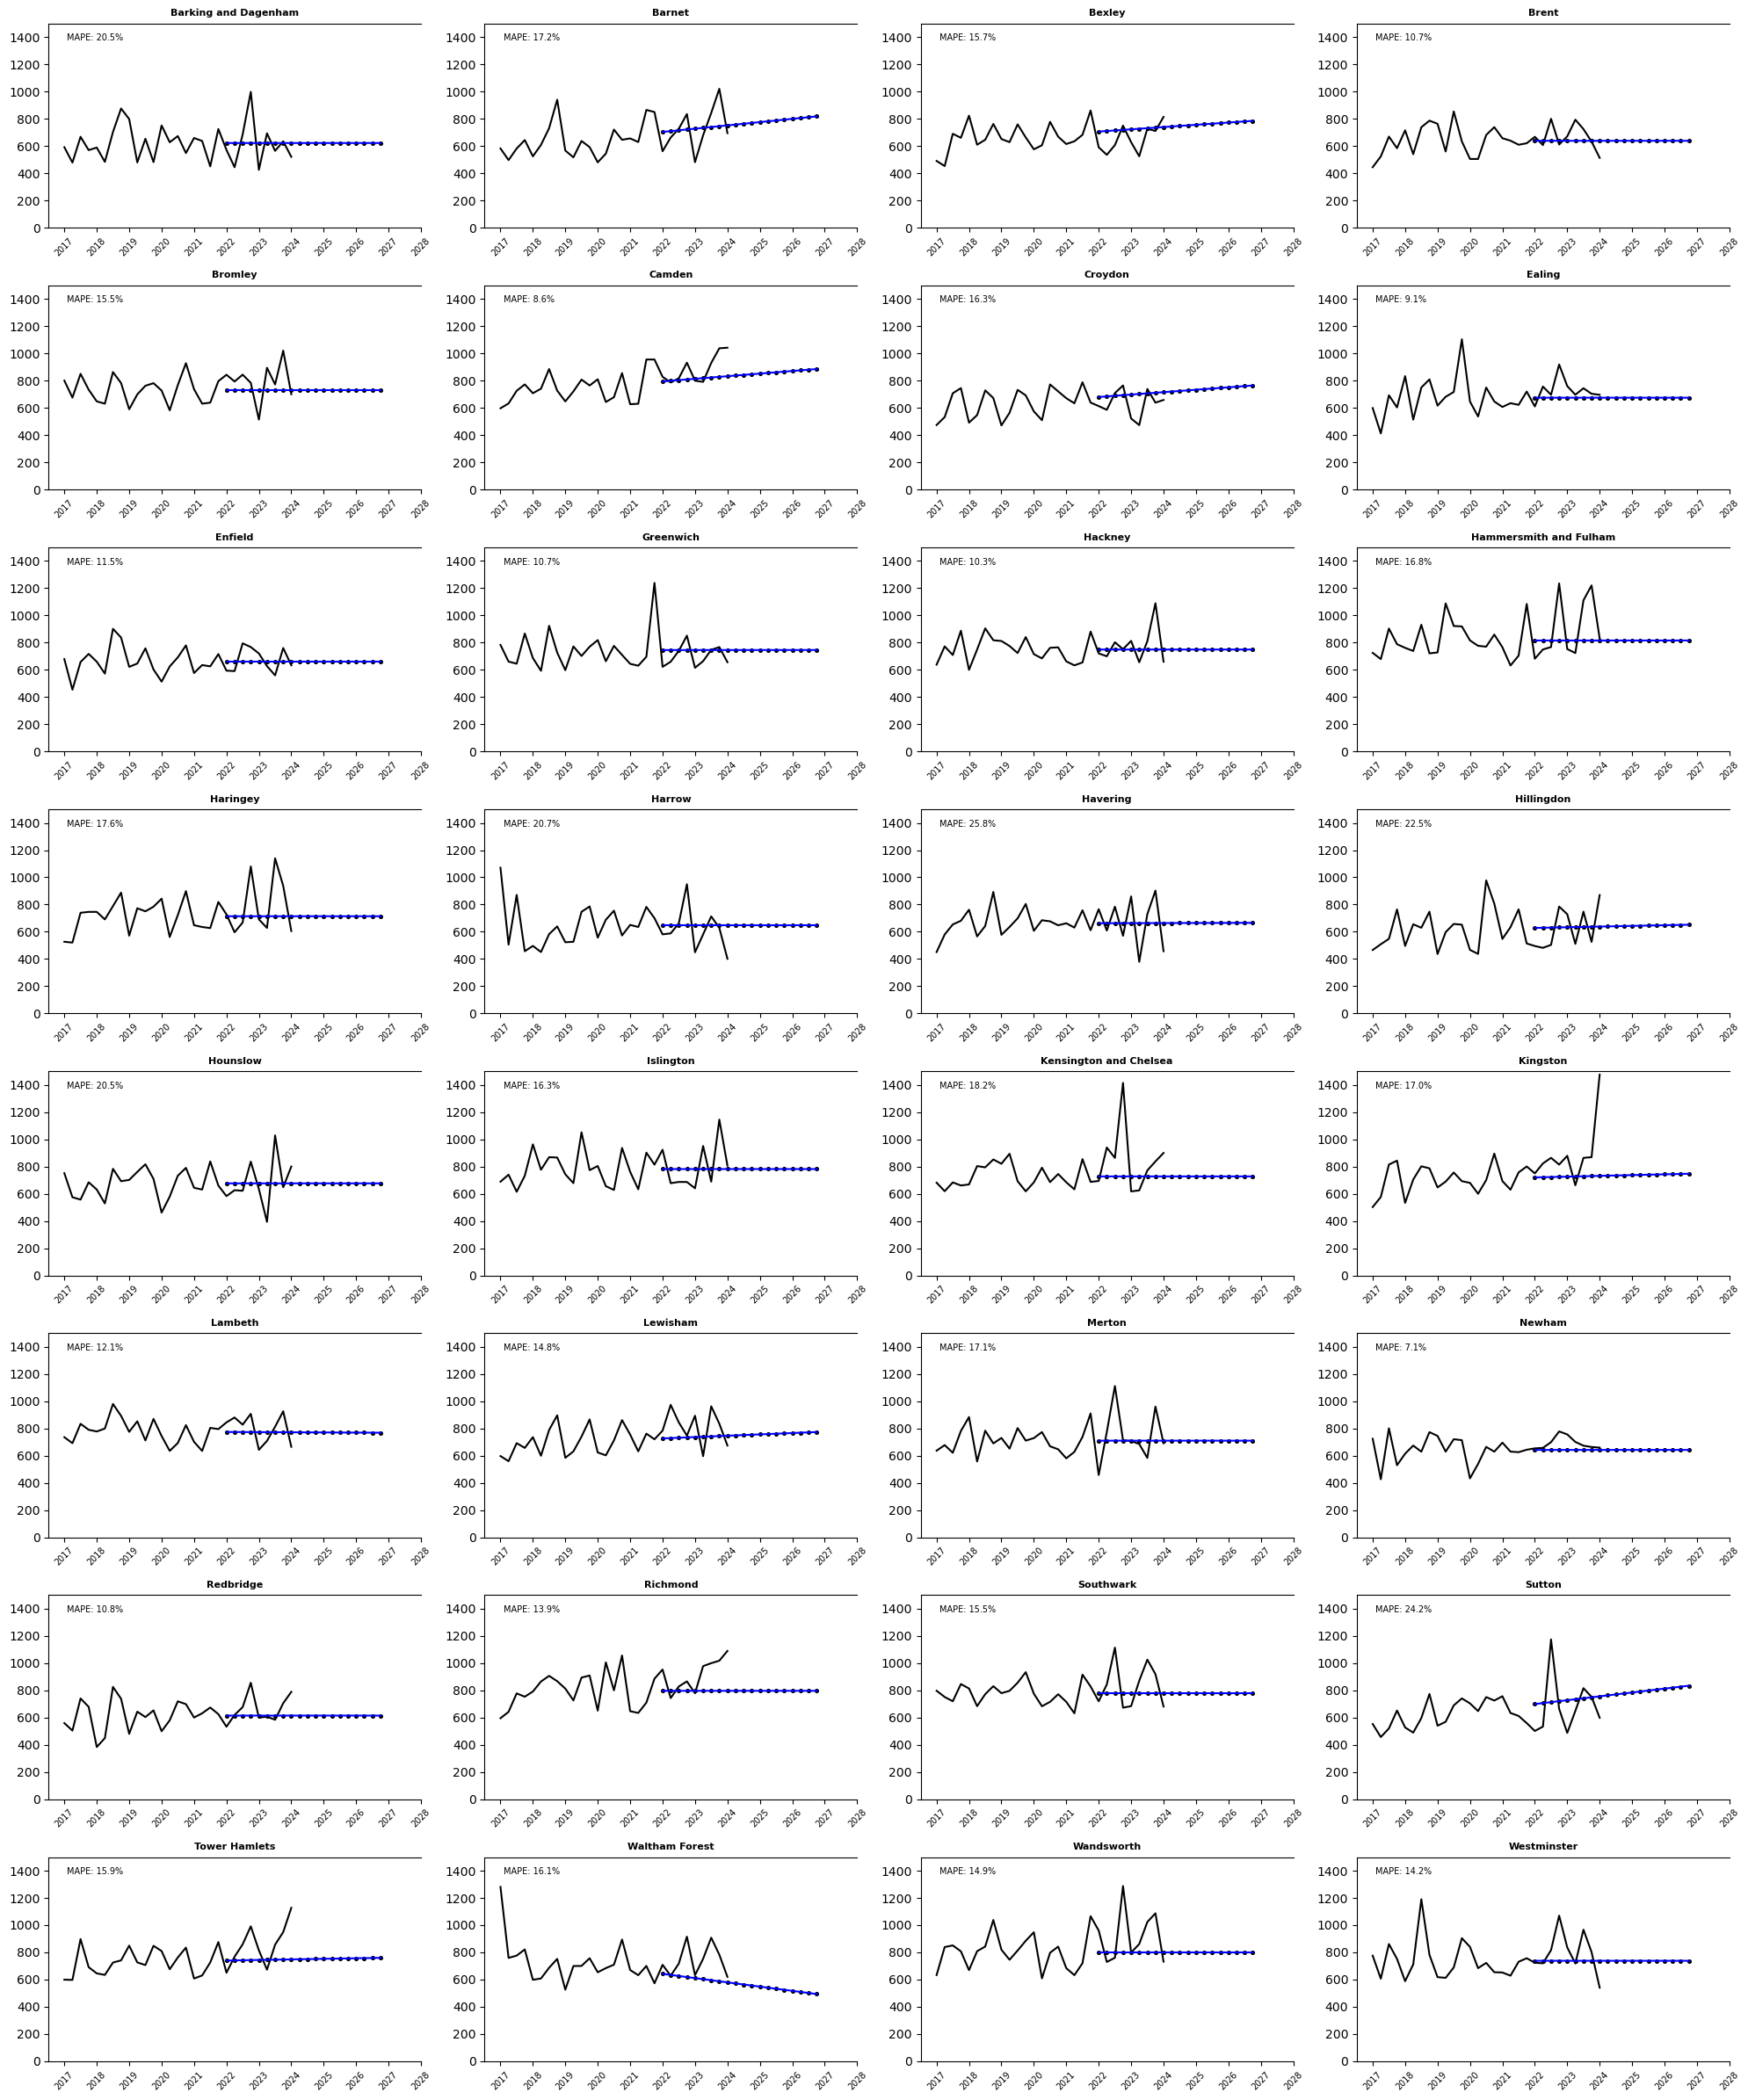

------------------------------
------- COVID ADJUSTED -------
------- BAYESIAN YEARLY ------
------------------------------
yearly average mape: 9.774876086818464


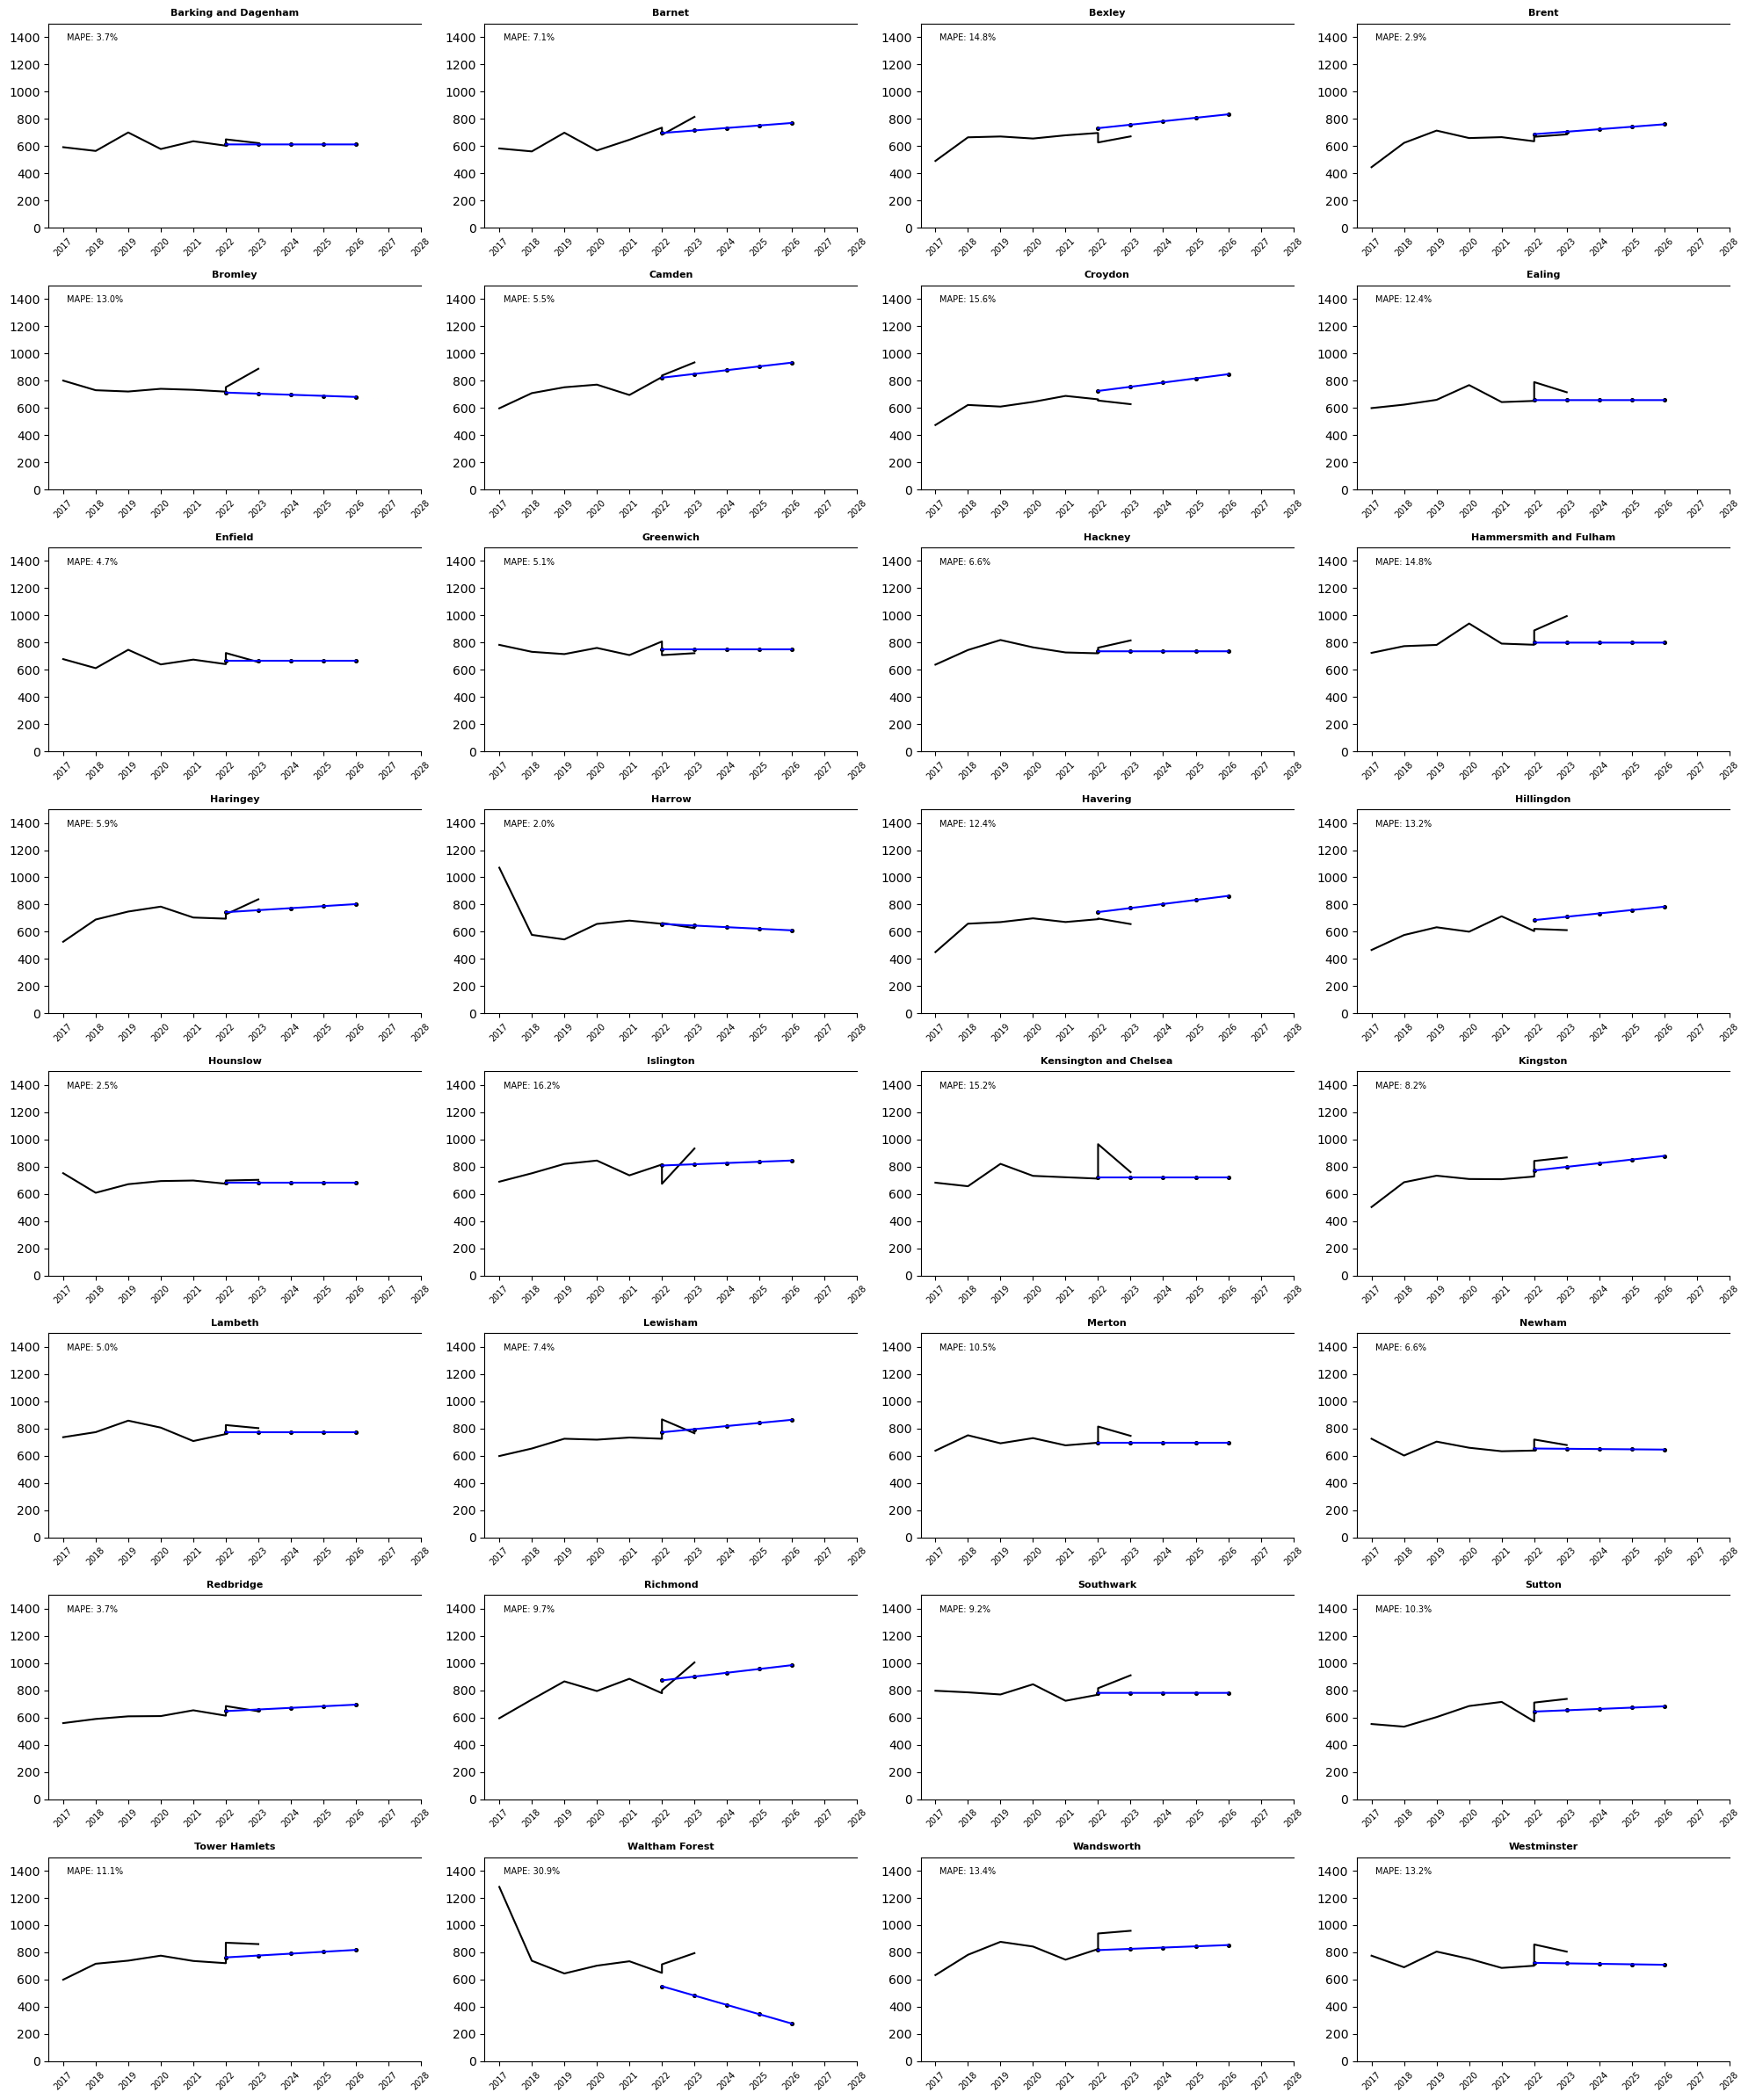

In [8]:
print("------------------------------")
print("------- SARIMA MONTHLY -------")
print("------------------------------")
print("average mape:", df_month_forecast['mape'].mean())
plot_borough_forecasts(df_month_forecast, 72, xtick_positions=month_positions, xtick_labels=year_labels)

print("------------------------------")
print("------ SARIMA QUARTERLY ------")
print("------------------------------")
print("SARIMA")
print("quarterly average mape:", df_quarter_forecast['mape'].mean())
plot_borough_forecasts(df_quarter_forecast, 20, xtick_labels=year_labels, xtick_positions=quarter_positions)

print('\n')
print("------------------------------")
print("------ BAYESIAN MONTHLY ------")
print("------------------------------")
print("monthly average mape:", df_bayesian_month_forecast['mape'].mean())
plot_borough_forecasts(df_bayesian_month_forecast, 72, xtick_positions=month_positions, xtick_labels=year_labels)

print("------------------------------")
print("----- BAYESIAN QUARTERLY -----")
print("------------------------------")
print("quarterly average mape:", df_bayesian_quarter_forecast['mape'].mean())
plot_borough_forecasts(df_bayesian_quarter_forecast, 20, xtick_labels=year_labels, xtick_positions=quarter_positions)

print("-------------------------------")
print("------- BAYESIAN YEARLY -------")
print("-------------------------------")
print("yearly average mape:", df_bayesian_year_forecast['mape'].mean())
plot_borough_forecasts(df_bayesian_year_forecast, 5, xtick_labels=year_labels, xtick_positions=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
print("\n\n")

print("------------------------------")
print("------- COVID ADJUSTED -------")
print("------- SARIMA MONTHLY -------")
print("------------------------------")
print("monthly average mape:", df_month_covid_forecast['mape'].mean())
plot_borough_forecasts(df_month_covid_forecast, 72, xtick_positions=month_positions, xtick_labels=year_labels)

print("------------------------------")
print("------- COVID ADJUSTED -------")
print("------ SARIMA QUARTERLY ------")
print("------------------------------")
print("quarterly average mape:", df_quarter_covid_forecast['mape'].mean())
plot_borough_forecasts(df_quarter_covid_forecast, 20, xtick_labels=year_labels, xtick_positions=quarter_positions)

print('\n')
print("------------------------------")
print("------- COVID ADJUSTED -------")
print("------ BAYESIAN MONTHLY ------")
print("------------------------------")
print("monthly average mape:", df_bayesian_month_covid_forecast['mape'].mean())
plot_borough_forecasts(df_bayesian_month_covid_forecast, 72, xtick_positions=month_positions, xtick_labels=year_labels)

print("------------------------------")
print("------- COVID ADJUSTED -------")
print("----- BAYESIAN QUARTERLY -----")
print("------------------------------")
print("quarterly average mape:", df_bayesian_quarter_covid_forecast['mape'].mean())
plot_borough_forecasts(df_bayesian_quarter_covid_forecast, 20, xtick_labels=year_labels, xtick_positions=quarter_positions)

print("------------------------------")
print("------- COVID ADJUSTED -------")
print("------- BAYESIAN YEARLY ------")
print("------------------------------")
print("yearly average mape:", df_bayesian_year_covid_forecast['mape'].mean())
plot_borough_forecasts(df_bayesian_year_covid_forecast, 5, xtick_labels=year_labels, xtick_positions=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

In [9]:
df_prophet_forecast = prophet_forecast(df_month, 72, 36)

13:59:37 - cmdstanpy - INFO - Chain [1] start processing
13:59:37 - cmdstanpy - INFO - Chain [1] done processing
13:59:37 - cmdstanpy - INFO - Chain [1] start processing
13:59:37 - cmdstanpy - INFO - Chain [1] done processing
13:59:37 - cmdstanpy - INFO - Chain [1] start processing
13:59:37 - cmdstanpy - INFO - Chain [1] done processing
13:59:37 - cmdstanpy - INFO - Chain [1] start processing
13:59:37 - cmdstanpy - INFO - Chain [1] done processing
13:59:37 - cmdstanpy - INFO - Chain [1] start processing
13:59:38 - cmdstanpy - INFO - Chain [1] done processing
13:59:38 - cmdstanpy - INFO - Chain [1] start processing
13:59:38 - cmdstanpy - INFO - Chain [1] done processing
13:59:38 - cmdstanpy - INFO - Chain [1] start processing
13:59:38 - cmdstanpy - INFO - Chain [1] done processing
13:59:38 - cmdstanpy - INFO - Chain [1] start processing
13:59:38 - cmdstanpy - INFO - Chain [1] done processing
13:59:38 - cmdstanpy - INFO - Chain [1] start processing
13:59:38 - cmdstanpy - INFO - Chain [1]

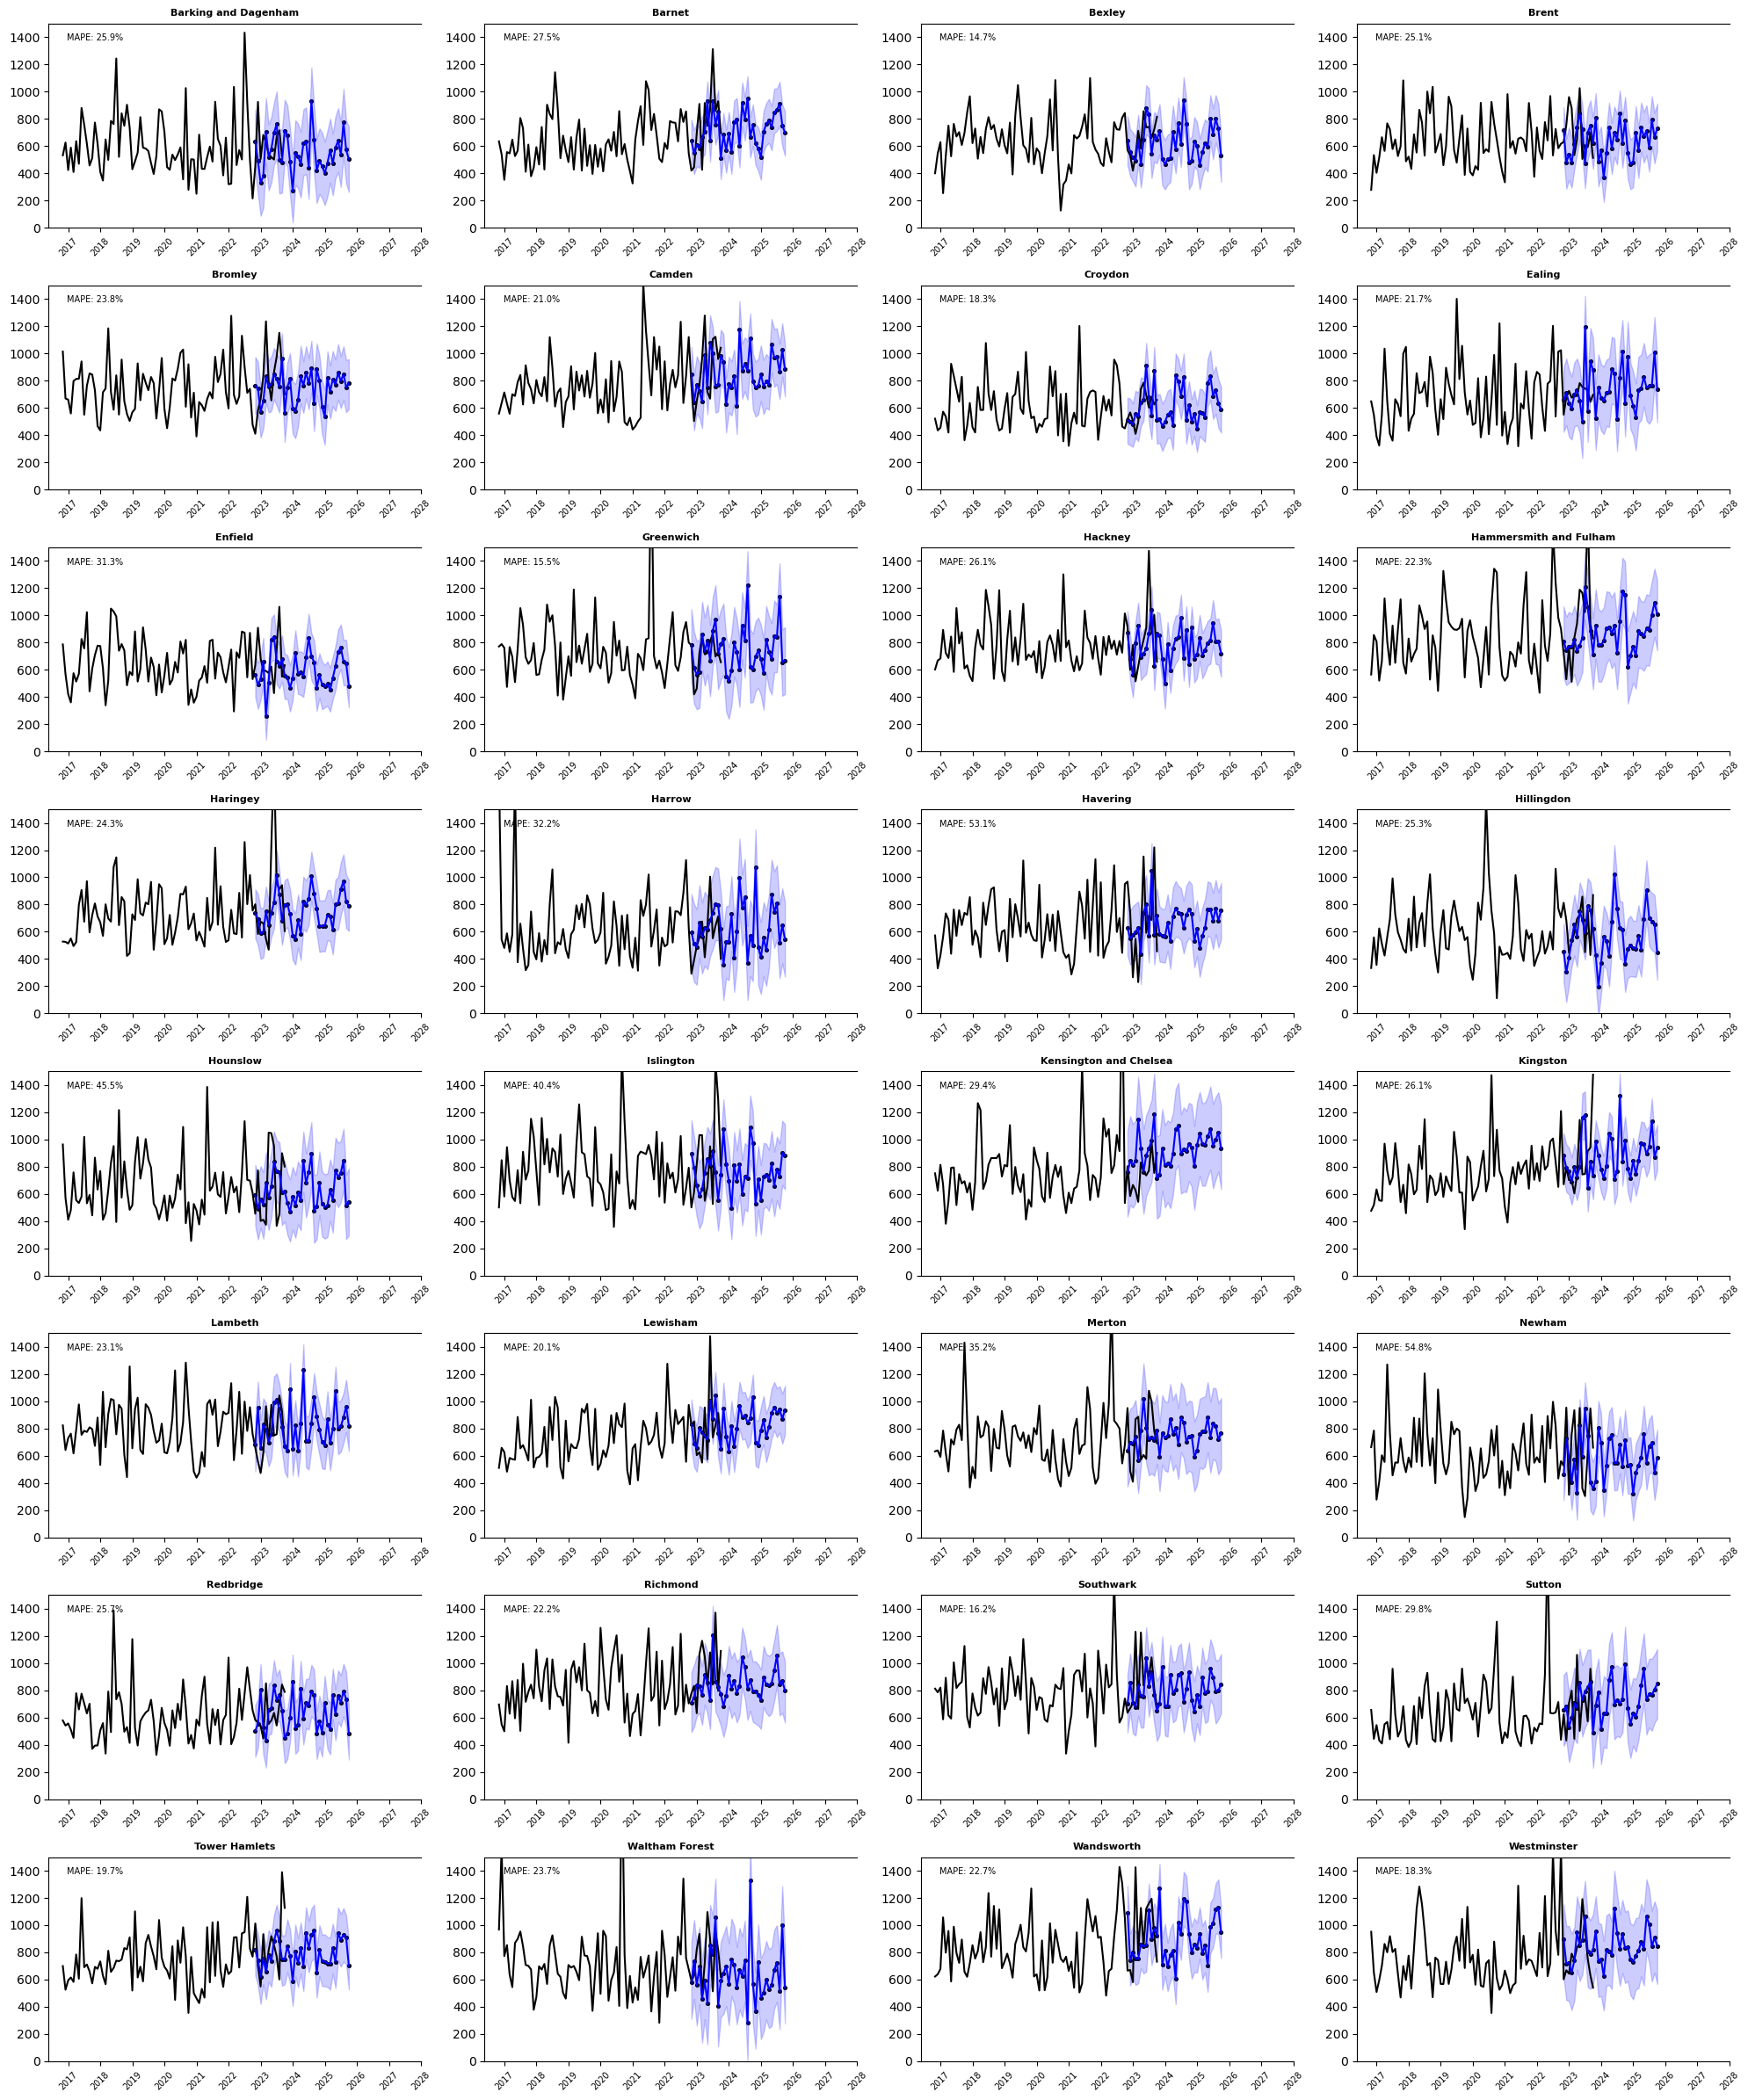

In [10]:
plot_prophet_forecasts(df_prophet_forecast, 72, xtick_positions=month_positions, xtick_labels=year_labels)

14:02:11 - cmdstanpy - INFO - Chain [1] start processing


14:02:11 - cmdstanpy - INFO - Chain [1] done processing
14:02:11 - cmdstanpy - INFO - Chain [1] start processing
14:02:11 - cmdstanpy - INFO - Chain [1] done processing
14:02:11 - cmdstanpy - INFO - Chain [1] start processing
14:02:11 - cmdstanpy - INFO - Chain [1] done processing
14:02:12 - cmdstanpy - INFO - Chain [1] start processing
14:02:12 - cmdstanpy - INFO - Chain [1] done processing
14:02:12 - cmdstanpy - INFO - Chain [1] start processing
14:02:12 - cmdstanpy - INFO - Chain [1] done processing
14:02:12 - cmdstanpy - INFO - Chain [1] start processing
14:02:12 - cmdstanpy - INFO - Chain [1] done processing
14:02:12 - cmdstanpy - INFO - Chain [1] start processing
14:02:12 - cmdstanpy - INFO - Chain [1] done processing
14:02:12 - cmdstanpy - INFO - Chain [1] start processing
14:02:12 - cmdstanpy - INFO - Chain [1] done processing
14:02:12 - cmdstanpy - INFO - Chain [1] start processing
14:02:12 - cmdstanpy - INFO - Chain [1] done processing
14:02:12 - cmdstanpy - INFO - Chain [1] 

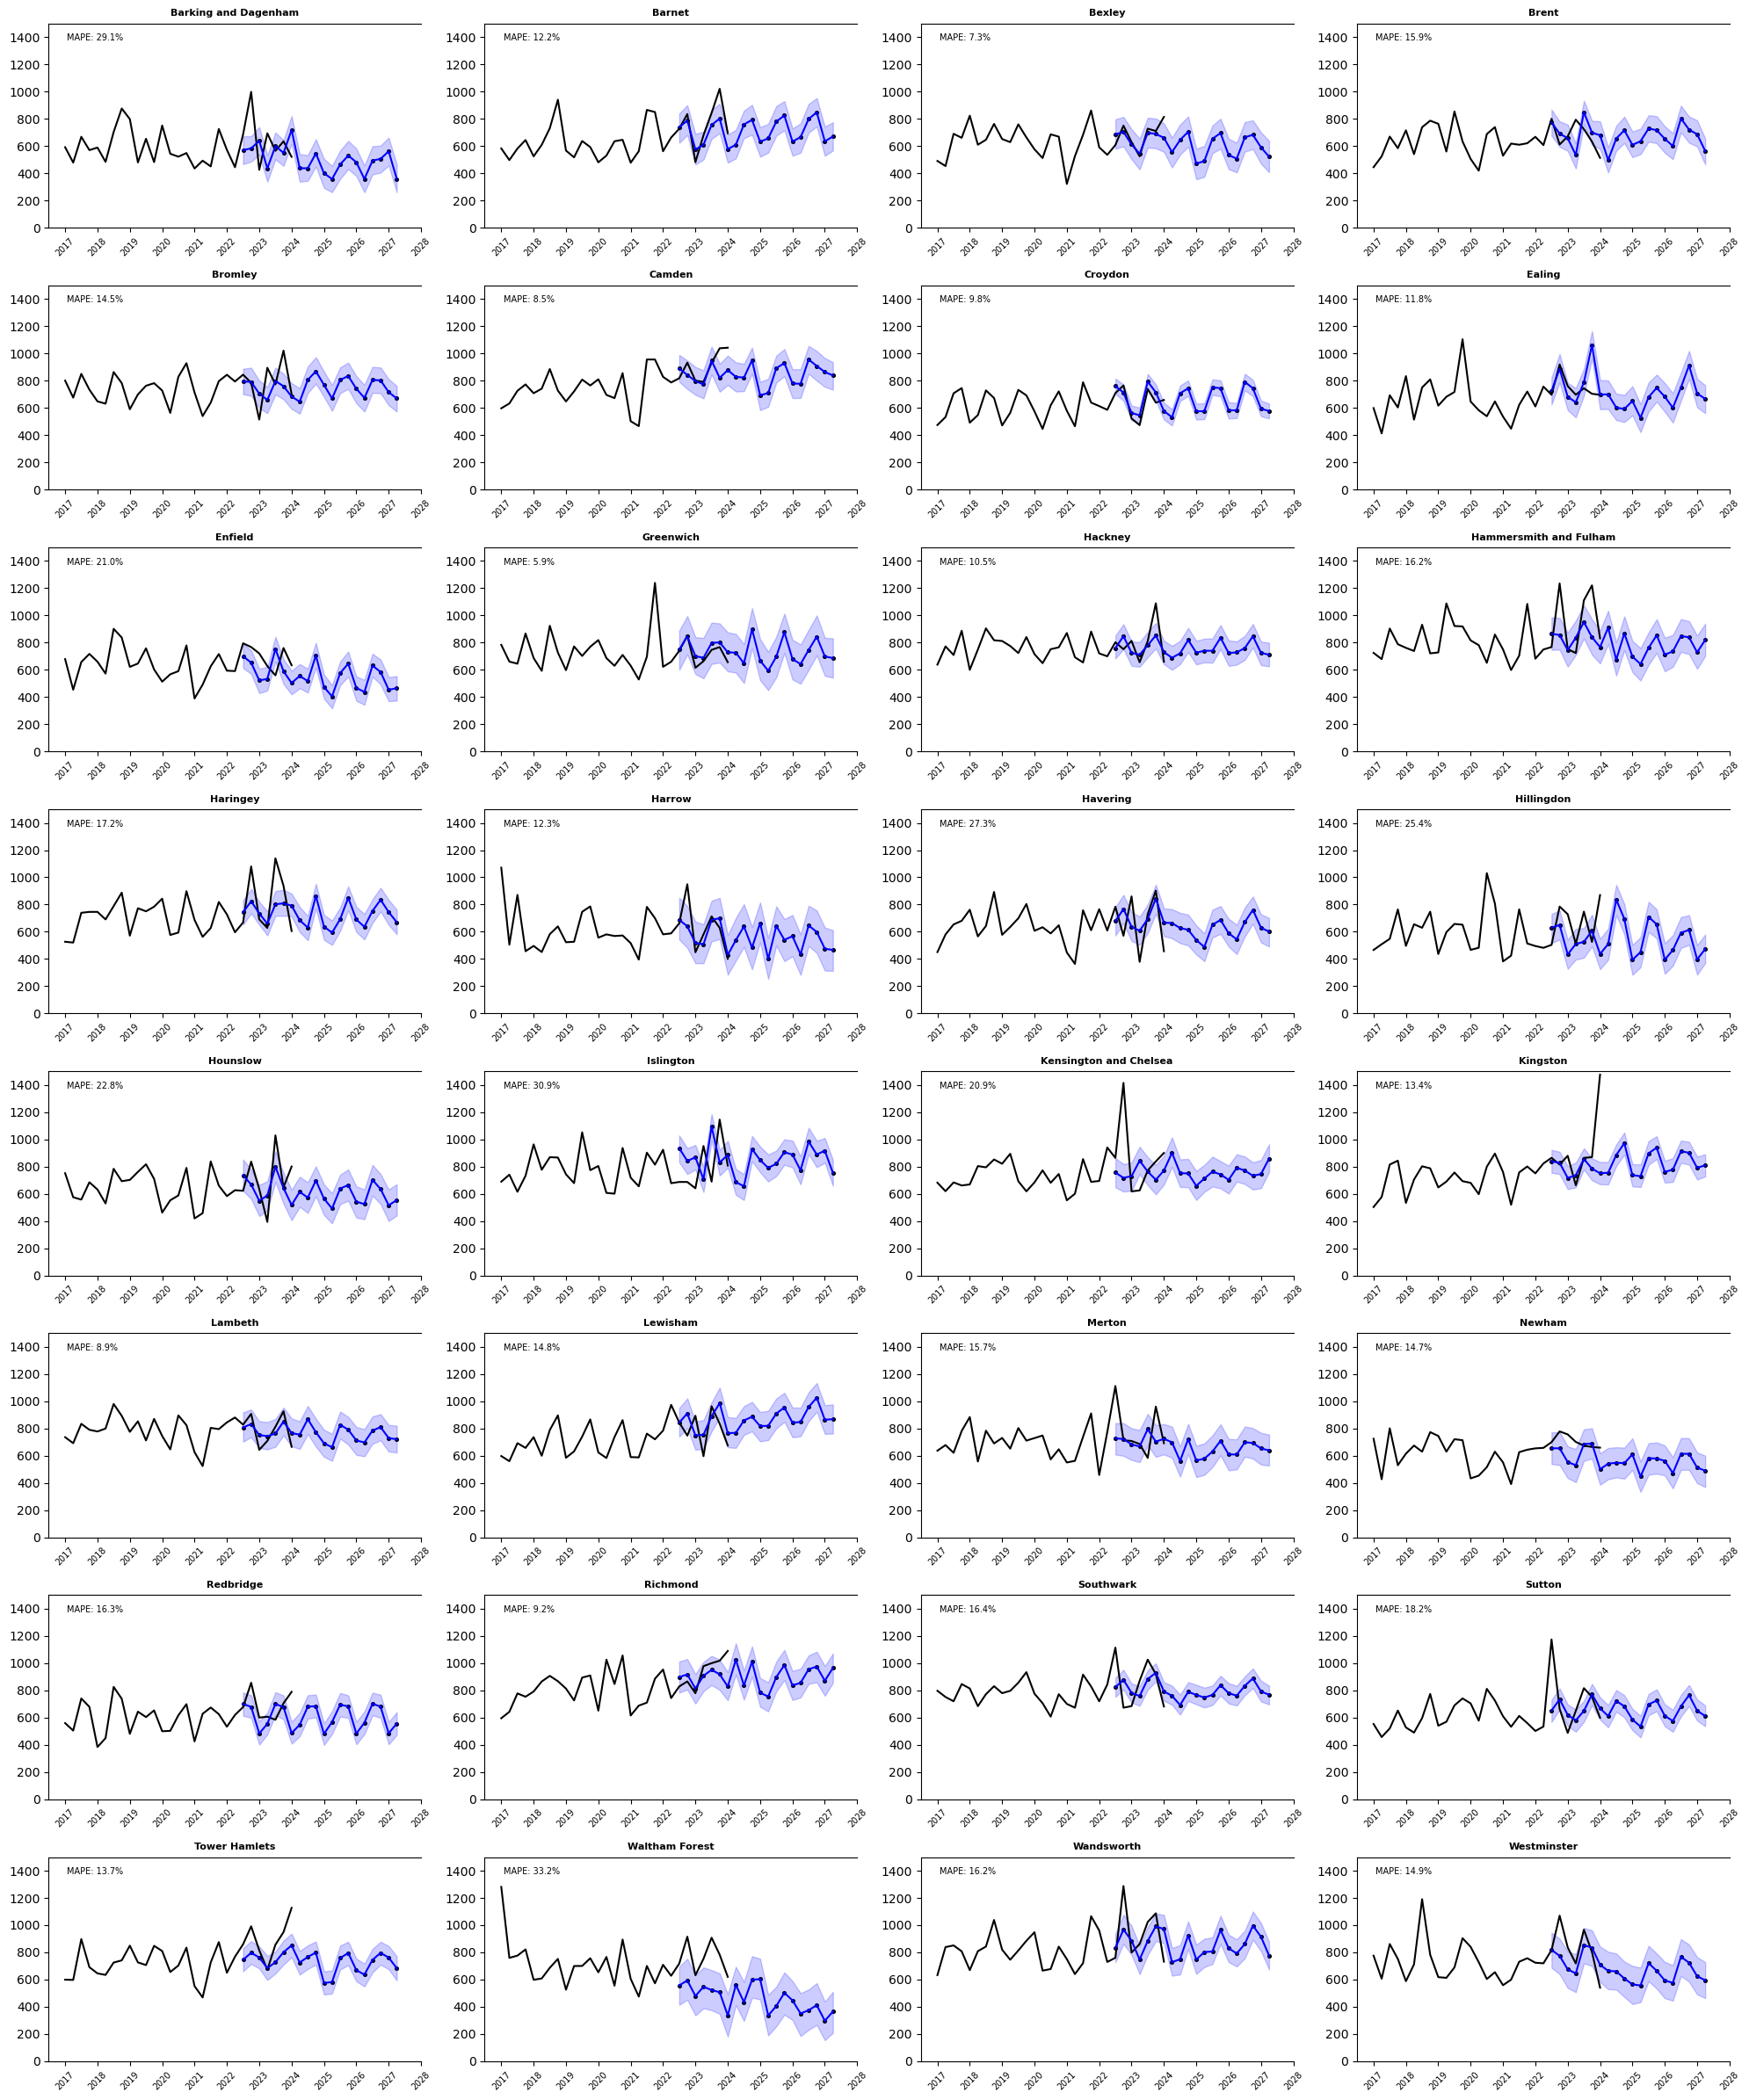

In [12]:
df_prophet_quarter = prophet_forecast(df_quarter, 22, 20)
plot_prophet_forecasts(df_prophet_quarter, 22, xtick_positions=quarter_positions, xtick_labels=year_labels)

In [19]:
print("quarter prophet", np.mean(df_prophet_quarter[['mape']]))

quarter prophet 16.41987808278576


In [18]:
print("monthly prophet", np.mean(df_prophet_forecast[['mape']]))

monthly prophet 26.895734316100278
